# CellRank analysis using the CytoTRACE kernal

https://cellrank.readthedocs.io/en/stable/notebooks/tutorials/kernels/400_cytotrace.html

## Import packages & data

In [ ]:
import sys
import os
import numpy as np
import pandas as pd
import anndata as ad
import cellrank as cr
import scanpy as sc
import scvelo as scv
from cellrank.kernels import CytoTRACEKernel
import warnings
warnings.filterwarnings('ignore')

cr.settings.verbosity = 2
sc.settings.set_figure_params(frameon=False, dpi=100)
scv.logging.print_version()
scv.settings.verbosity = 3  # show errors(0), warnings(1), info(2), hints(3)
scv.settings.presenter_view = True  # set max width size for presenter view
scv.set_figure_params()  # for beautified visualization

/tmp/ipykernel_113289/758847504.py:4: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Running scvelo 0.3.1 (python 3.11.5) on 2024-02-20 20:58.


ERROR: XMLRPC request failed [code: -32500]
RuntimeError: PyPI no longer supports 'pip search' (or XML-RPC search). Please use https://pypi.org/search (via a browser) instead. See https://warehouse.pypa.io/api-reference/xml-rpc.html#deprecated-methods for more information.


## Load data

The dataset contains 3 time-points (days 7, 9, & 11) of iPSCs cell development for wtGATA and GATA1s genotype mutation samples

In [ ]:
# Load anndata file converted from Seurat integrated object
adata = scv.read("../seurat_objects/timecourse-d7911-renamed-merged.h5ad")
adata

AnnData object with n_obs × n_vars = 148750 × 29918
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'seurat_clusters', 'integrated_snn_res.0.4', 'cell_type', 'S.Score', 'G2M.Score', 'Phase', 'barcode', 'condition', 'genotype', 'time', 'sample_batch', 'batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand'
    uns: 'cell_type_colors', 'time_colors'
    obsm: 'X_pca', 'X_umap_integrated', 'X_umap_merged'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'

In [ ]:
# # subset for Seurat ingration variable genes
# seurat_genes = pd.read_csv("../results/timecourse/timecourse-d7911-umap-renamed-variable-genes.txt", names=["gene"])
# seurat_genes = set(seurat_genes['gene'].values).intersection(adata.var_names)
# adata =  adata[:, list(seurat_genes)]
# adata

## Preprocess data

Basic preprocessing of the data before applying the CytoTRACE kernel

In [ ]:
# filter, normalize total counts and log-transform
sc.pp.filter_genes(adata, min_cells = 3)
scv.pp.normalize_per_cell(adata, enforce=True)
sc.pp.log1p(adata)

# hvg annotation
sc.pp.highly_variable_genes(adata, n_top_genes = 6000)
print(f"This detected {adata.var['highly_variable'].sum()} highly variable genes. ")
adata

Normalized count data: X, spliced, unspliced.
This detected 6000 highly variable genes. 


AnnData object with n_obs × n_vars = 148750 × 29918
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'seurat_clusters', 'integrated_snn_res.0.4', 'cell_type', 'S.Score', 'G2M.Score', 'Phase', 'barcode', 'condition', 'genotype', 'time', 'sample_batch', 'batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'n_cells', 'gene_count_corr', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'cell_type_colors', 'time_colors', 'log1p', 'hvg'
    obsm: 'X_pca', 'X_umap_integrated', 'X_umap_merged'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'

CytoTRACE uses imputed gene expression to calculate the score of differentiation potential. Here, we use use scvelo.pp.moments() for imputation. We’re copying our X matrix into the layers because that’s where moments() expects to find counts for imputation

In [ ]:
adata.layers["spliced"] = adata.X
adata.layers["unspliced"] = adata.X
scv.pp.moments(adata, n_pcs=30, n_neighbors=50)

computing neighbors
    finished (0:01:44) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:11:16) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


## Use developmental potential to direct differentiation

Compute the CytoTRACE score and check if psuedotime the relates to time and expected annotated cell type differention

Computing CytoTRACE score with `29918` genes
Adding `adata.obs['ct_score']`
       `adata.obs['ct_pseudotime']`
       `adata.obs['ct_num_exp_genes']`
       `adata.var['ct_gene_corr']`
       `adata.var['ct_correlates']`
       `adata.uns['ct_params']`
    Finish (0:00:27)
saving figure to file ./figures/scvelo_cytoTRACE_umap_pseudotimeTimeCell_type_integrated.png


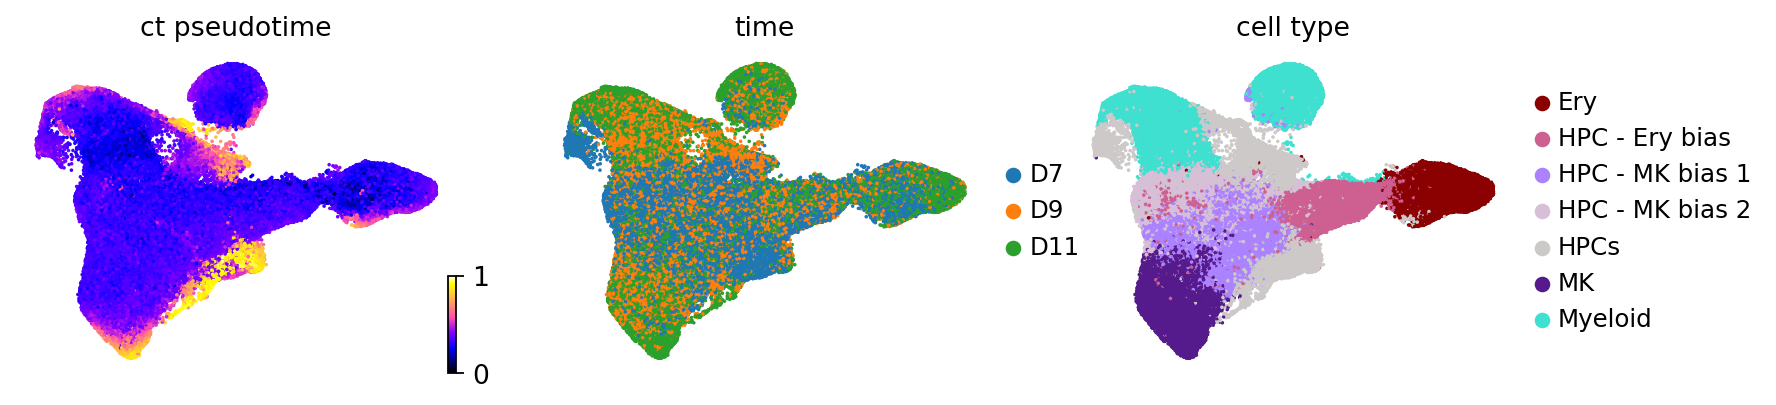

In [ ]:
#integrated UMAP
warnings.filterwarnings('ignore')
ctk = CytoTRACEKernel(adata).compute_cytotrace()
scv.pl.scatter(
    adata,
    c=["ct_pseudotime", "time", "cell_type"],
    basis="umap_integrated",
    legend_loc="right",
    color_map="gnuplot2",
    sort_order = False,
    save = "cytoTRACE_umap_pseudotimeTimeCell_type_integrated.png"
)

saving figure to file ./figures/scvelo_cytoTRACE_umap_pseudotimeTimeCell_type_merged.png


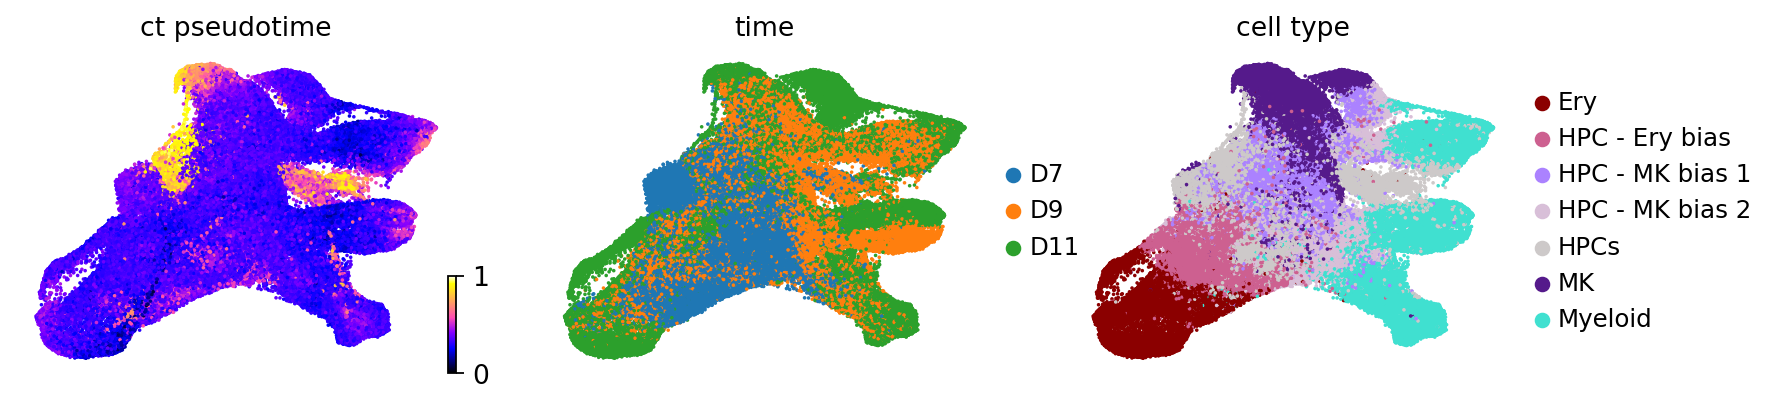

In [ ]:
# merged UMAP
warnings.filterwarnings('ignore')
scv.pl.scatter(
    adata,
    c=["ct_pseudotime", "time", "cell_type"],
    basis="umap_merged",
    legend_loc="right",
    color_map="gnuplot2",
    sort_order = False,
    save = "cytoTRACE_umap_pseudotimeTimeCell_type_merged.png"
)

Compute & visualize a transition matrix

In [ ]:
ctk.compute_transition_matrix(threshold_scheme="soft", nu=0.5)

Computing transition matrix based on pseudotime


  0%|          | 0/148750 [00:00<?, ?cell/s]

    Finish (0:01:04)


CytoTRACEKernel[n=148750, dnorm=False, scheme='soft', b=10.0, nu=0.5]

Projecting transition matrix onto `umap_integrated`
Adding `adata.obsm['T_fwd_umap_integrated']`
    Finish (0:00:51)


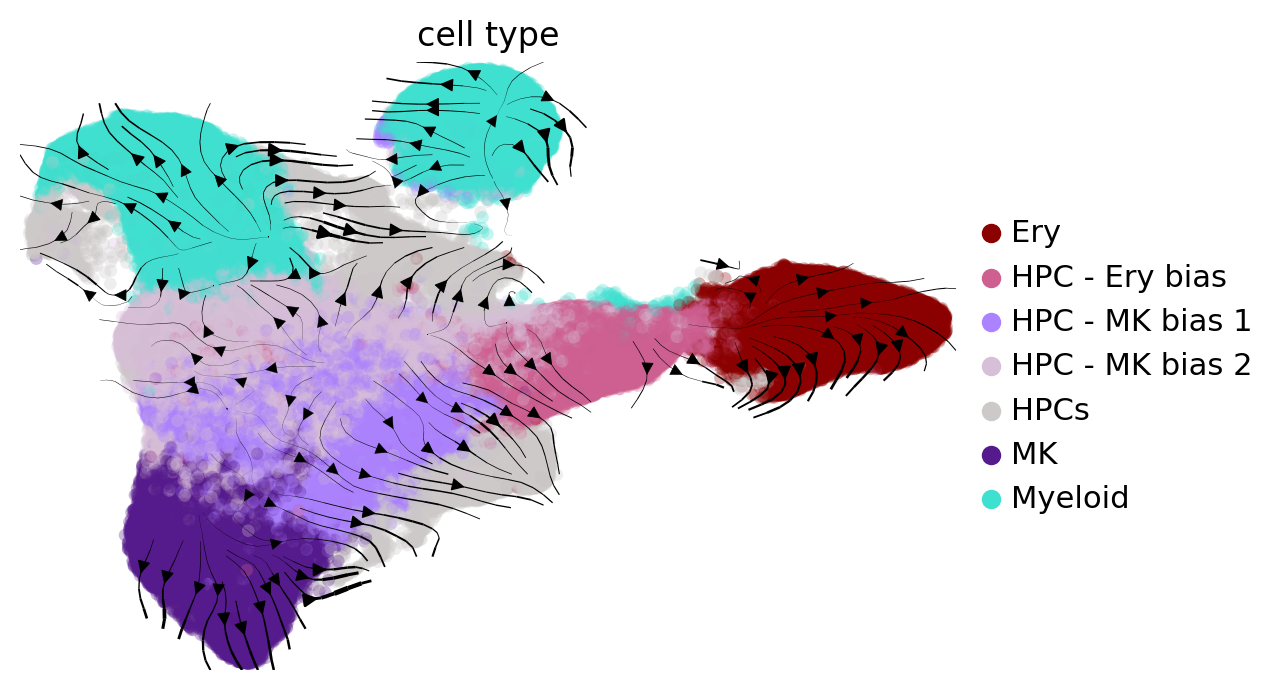

AnnData object with n_obs × n_vars = 148750 × 29918
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'seurat_clusters', 'integrated_snn_res.0.4', 'cell_type', 'S.Score', 'G2M.Score', 'Phase', 'barcode', 'condition', 'genotype', 'time', 'sample_batch', 'batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'ct_score', 'ct_pseudotime', 'ct_num_exp_genes'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'n_cells', 'gene_count_corr', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'ct_gene_corr', 'ct_correlates'
    uns: 'cell_type_colors', 'time_colors', 'log1p', 'hvg', 'neighbors', 'ct_params', 'T_fwd_params'
    obsm: 'X_pca', 'X_umap_integrated', 'X_umap_merged', 'T_fwd_umap_integrated'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced', 'Ms', 'Mu'
    obsp: 'distances', 'connectivities'

In [ ]:
# function ctk.compute_projection() nolonger avalable - run the plot function to get transition projections
# before plotting with scv.pl.velocity_embedding_stream for better visuals
warnings.filterwarnings('ignore')
ctk.plot_projection(basis="umap_integrated", color = "cell_type", legend_loc="right")
adata

saving figure to file ./figures/scvelo_cytoTRACE_umap_cell_type_integrated.png


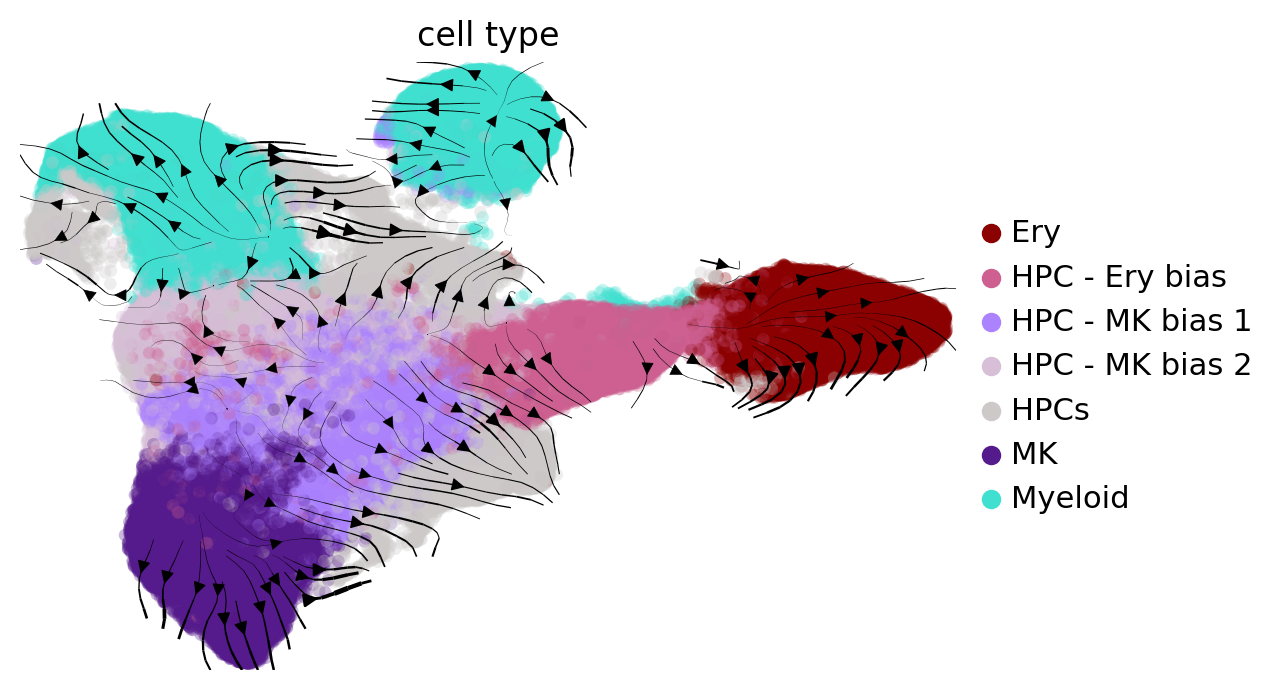

In [ ]:
warnings.filterwarnings('ignore')
scv.pl.velocity_embedding_stream(adata, color="cell_type", vkey="T_fwd", basis="umap_integrated",
                                 legend_loc="right", sort_order = False,
                                 save = "cytoTRACE_umap_cell_type_integrated.png")

saving figure to file ./figures/scvelo_cytoTRACE_umap_time_integrated.png


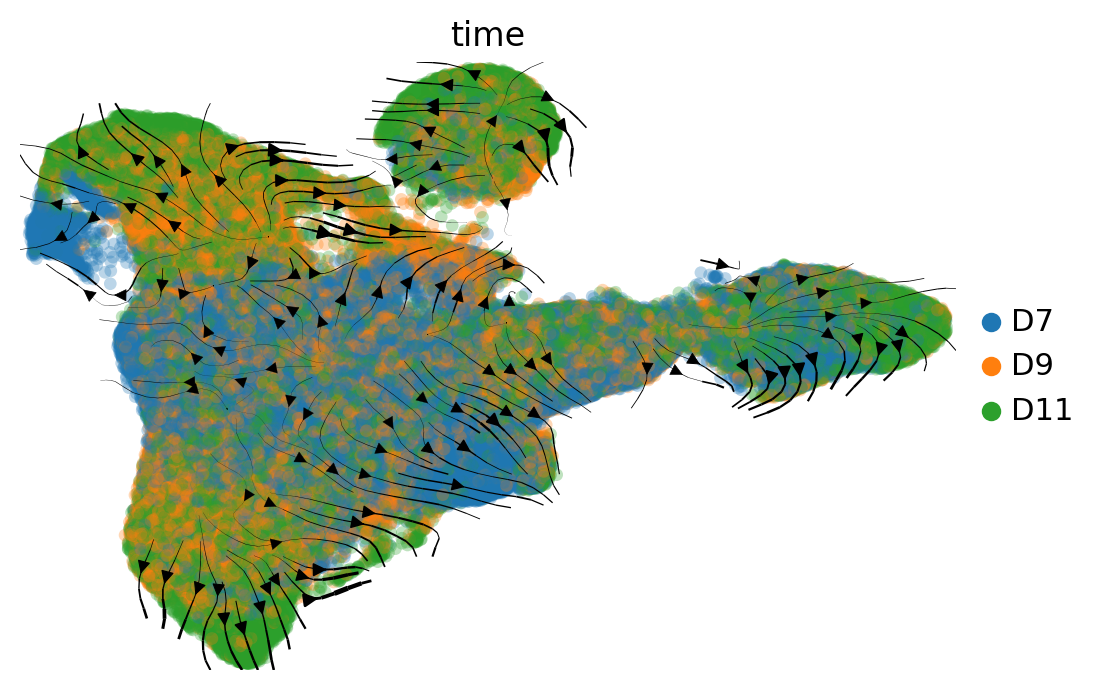

In [ ]:
warnings.filterwarnings('ignore')
scv.pl.velocity_embedding_stream(adata, color="time", vkey="T_fwd", basis="umap_integrated",
                                 legend_loc="right",  sort_order = False,
                                 save = "cytoTRACE_umap_time_integrated.png")

saving figure to file ./figures/scvelo_cytoTRACE_umap_pseudotime_type_integrated.png


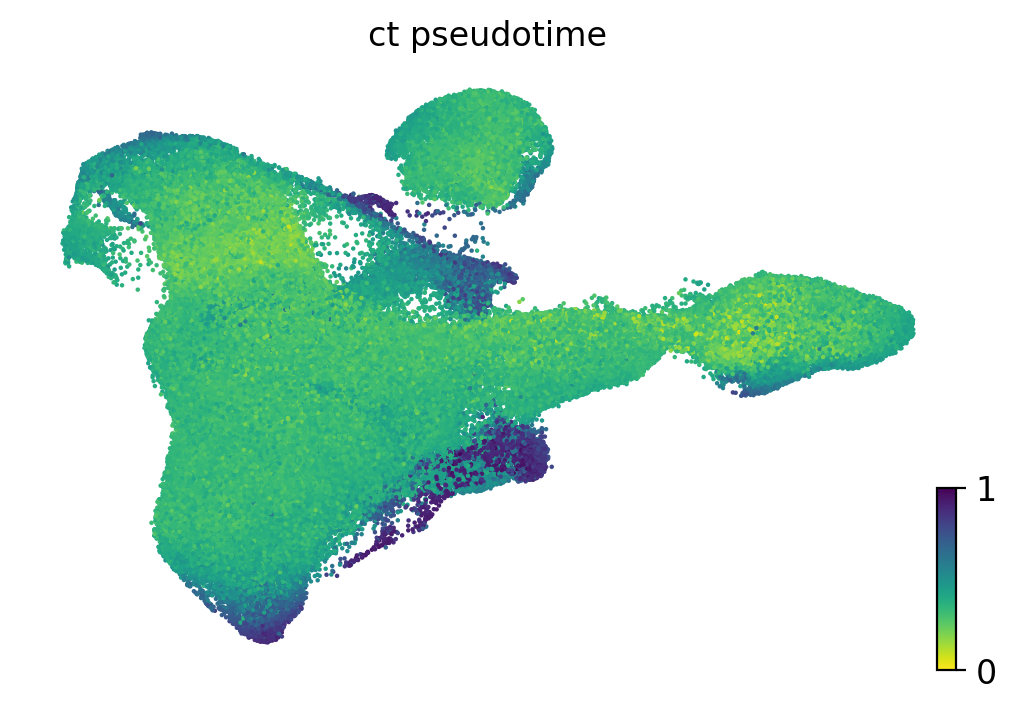

In [ ]:
warnings.filterwarnings('ignore')
scv.pl.scatter(adata, basis="umap_integrated", color="ct_pseudotime", sort_order = False,
               save = "cytoTRACE_umap_pseudotime_type_integrated.png")

## Computing terminal States

In [ ]:
adata.obs.columns

Index(['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt',
       'seurat_clusters', 'integrated_snn_res.0.4', 'cell_type', 'S.Score',
       'G2M.Score', 'Phase', 'barcode', 'condition', 'genotype', 'time',
       'sample_batch', 'batch', 'initial_size_unspliced',
       'initial_size_spliced', 'initial_size', 'n_counts', 'ct_score',
       'ct_pseudotime', 'ct_num_exp_genes'],
      dtype='object')

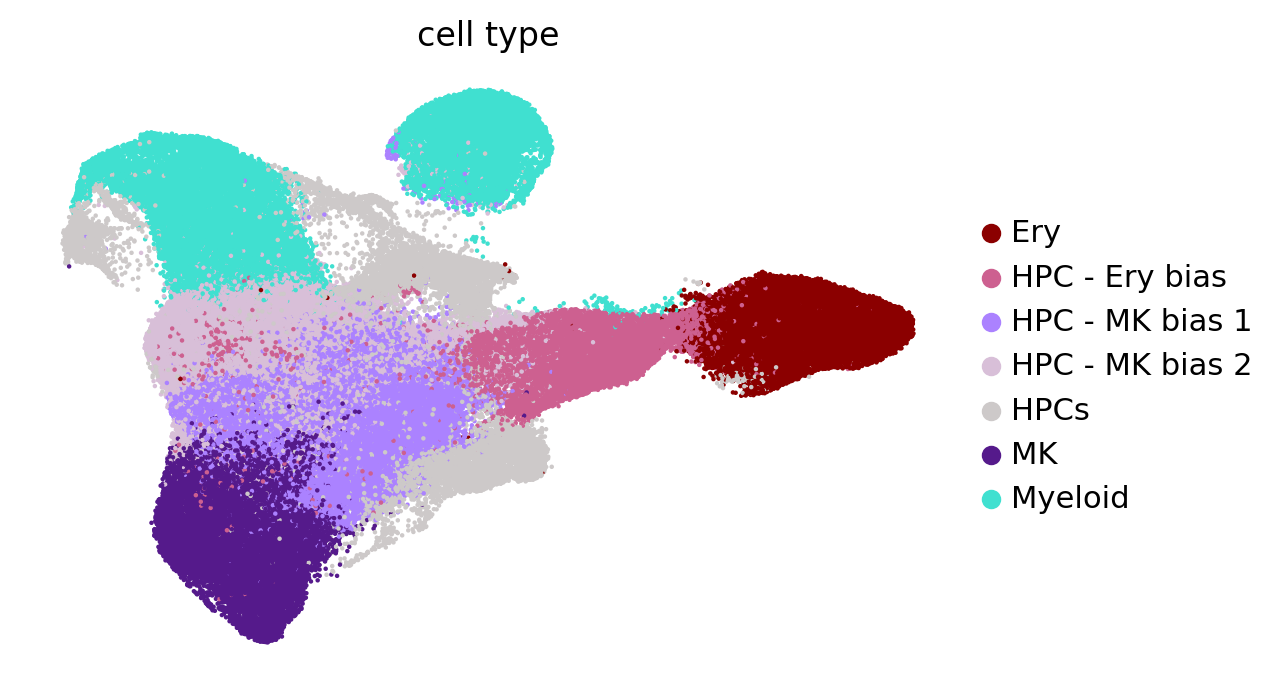

In [ ]:
# Itegrated UMAP with cluster labels
warnings.filterwarnings('ignore')
scv.pl.scatter(adata, basis="umap_integrated", color="cell_type", legend_loc="right", sort_order = False)

In [ ]:
## Initialize an estimator to compute initial and terminal states
g = cr.estimators.GPCCA(ctk)
print(g)

GPCCA[kernel=CytoTRACEKernel[n=148750], initial_states=None, terminal_states=None]


Computing Schur decomposition
Adding `adata.uns['eigendecomposition_fwd']`
       `.schur_vectors`
       `.schur_matrix`
       `.eigendecomposition`
    Finish (0:00:32)


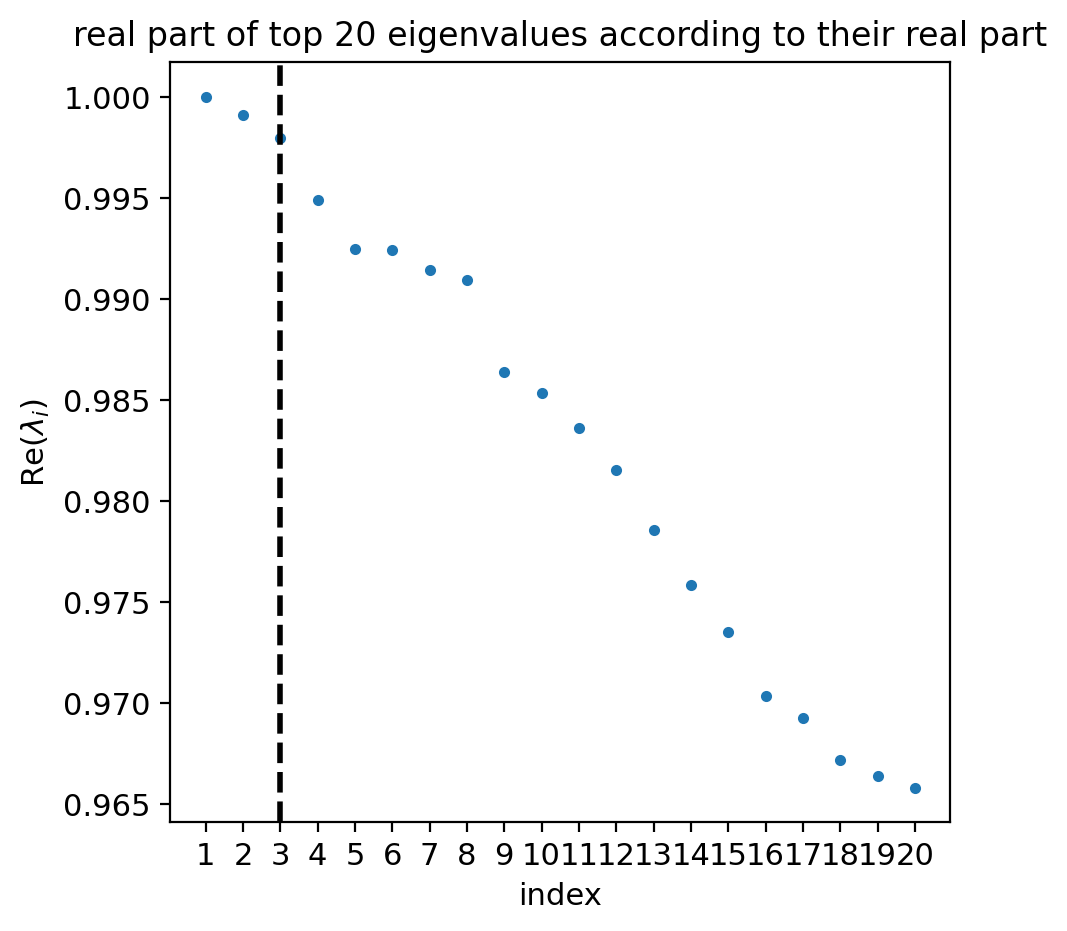

In [ ]:
# Compute microstates based on the real Shur decomposition
# and plot the top 20 real part of the eigenvalues
g.compute_schur(n_components=20)
g.plot_spectrum(real_only=True)

Using the real Schur decomposition to compute macrostatesm the estimator automatically suggests 1 state to use (dashed vertical line). I ignore that and compute a bit more states to have a chance at identifying the three expetected terminal state populations (Ery, MK, Myeloid).

Computing `7` macrostates
Adding `.macrostates`
       `.macrostates_memberships`
       `.coarse_T`
       `.coarse_initial_distribution
       `.coarse_stationary_distribution`
       `.schur_vectors`
       `.schur_matrix`
       `.eigendecomposition`
    Finish (0:01:06)
saving figure to file ./figures/scvelo_cytoTRACE_all_predicted_macrostates.png


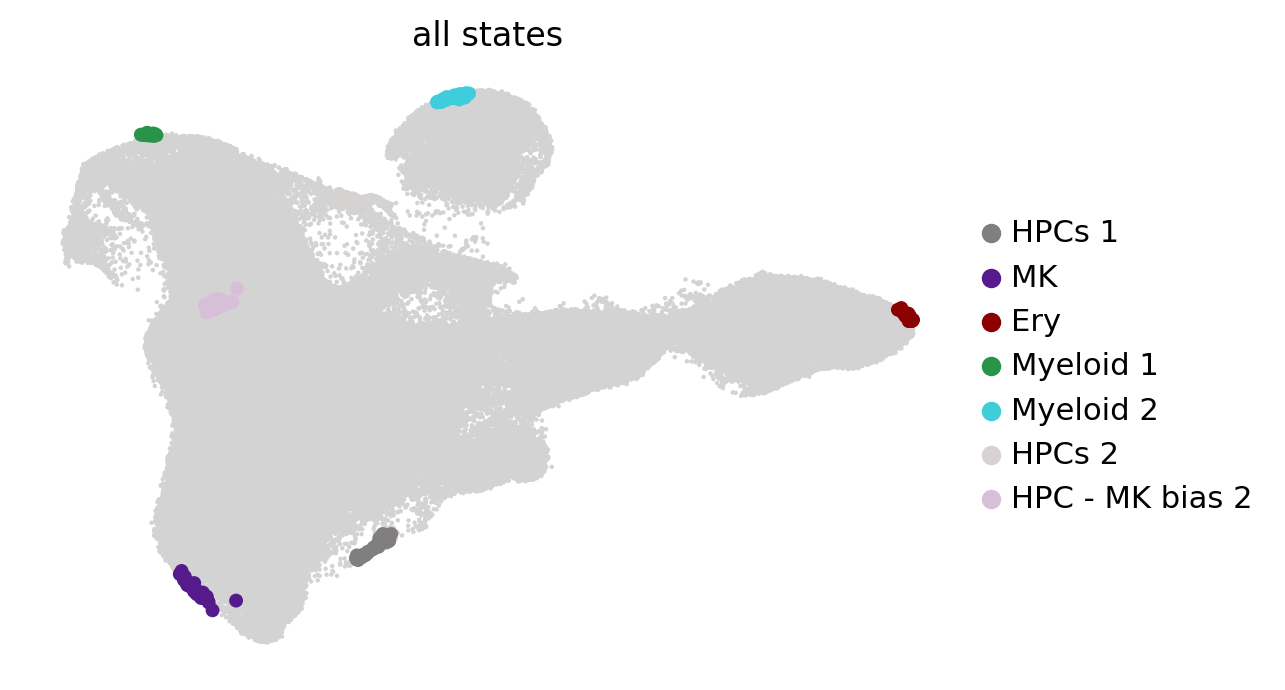

In [ ]:
warnings.filterwarnings('ignore')
g.compute_macrostates(n_states=7, n_cells=30, cluster_key="cell_type")
g.plot_macrostates(which="all", basis="umap_integrated", legend_loc="right", s=100, discrete=True,
                   save="cytoTRACE_all_predicted_macrostates.png")

In [ ]:
# microstate distribution
# g.plot_macrostate_composition(key="cell_type", figsize=(7, 4),
#                               save="cytoTRACE_all_predicted_macrostates_composition.png")

By default, macrostates are ordered according to their diagonal value, increasing from left to right. The diagonal value is a proxy for a states’ metastability, i.e. the probability of leaving the state once entered.
Interestingly, all microstates have high values. Suggesting all terminal states?

In [ ]:
# To get an idea of how these macrostates are related, we plot the coarse-grained transition matrix produces GPCCA
# g.plot_coarse_T(annotate=False, save="cytoTRACE_all_predicted_macrostates_metastability,.png")

Automated terminal state identification

Adding `adata.obs['term_states_fwd']`
       `adata.obs['term_states_fwd_probs']`
       `.terminal_states`
       `.terminal_states_probabilities`
       `.terminal_states_memberships
    Finish`


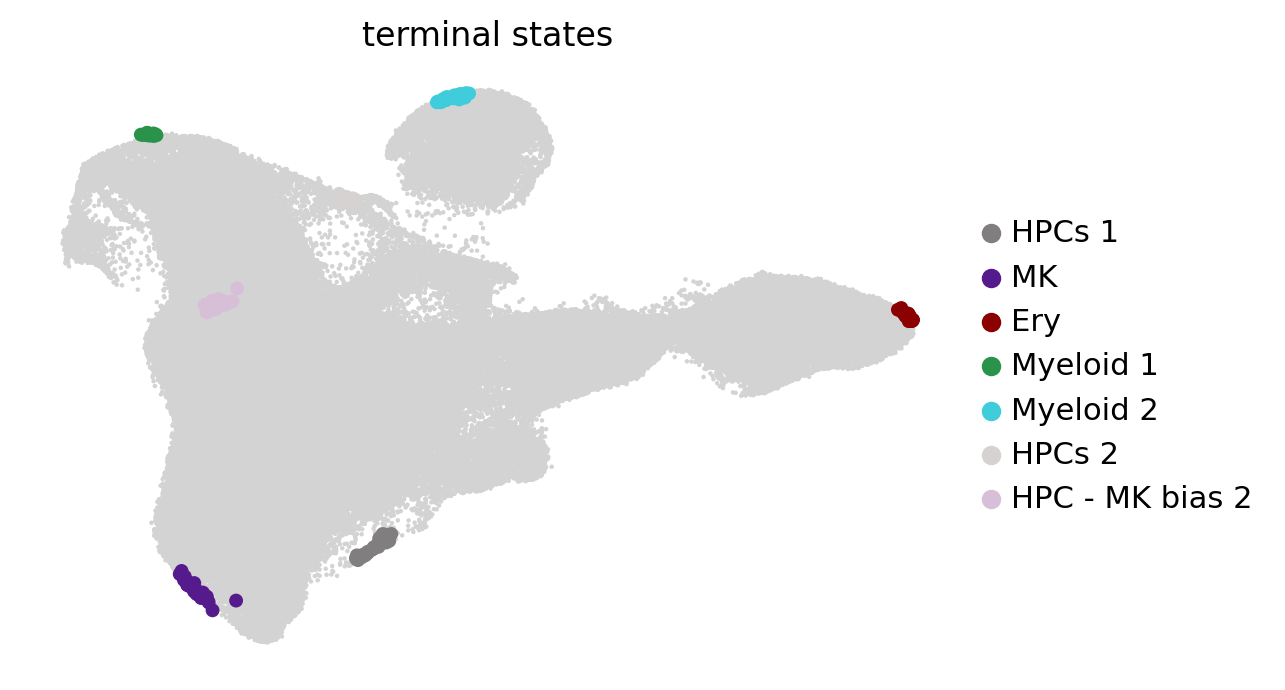

In [ ]:
g.predict_terminal_states()
g.plot_macrostates(which="terminal", basis="umap_integrated", legend_loc="right", s=100)

Since terminal cell types of erach lineage are known, using semi-automated terminal state identification to select top stable Ery, MK and Myeloid terminal states. Are within the to 7 predicted states with myeloid split into two terminal branches (subpolulations). Ignoring all other proceeding states.

Adding `adata.obs['term_states_fwd']`
       `adata.obs['term_states_fwd_probs']`
       `.terminal_states`
       `.terminal_states_probabilities`
       `.terminal_states_memberships
    Finish`
saving figure to file ./figures/scvelo_cytoTRACE_terminal_predicted_macrostates.png


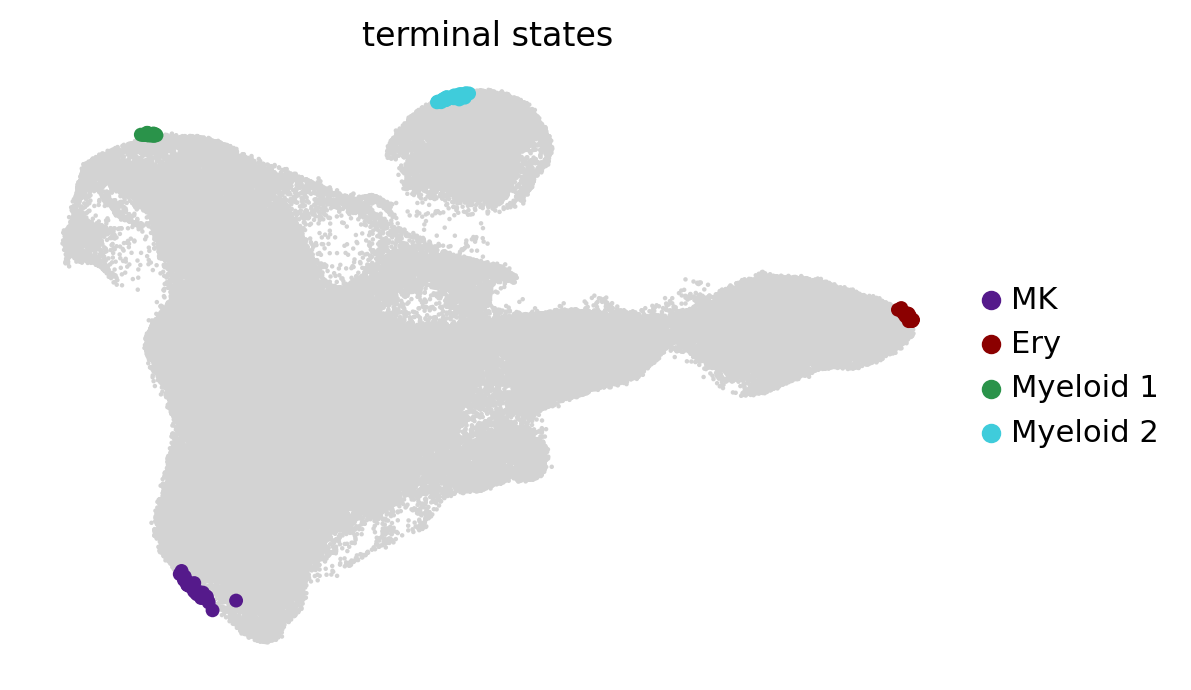

In [ ]:
warnings.filterwarnings('ignore')
g.set_terminal_states(states=["MK", "Ery", "Myeloid_1", "Myeloid_2"], allow_overlap=True)
g.plot_macrostates(which="terminal", basis="umap_integrated",  legend_loc="right", s=100, discrete=True,
                   save="cytoTRACE_terminal_predicted_macrostates.png")

In [ ]:
adata

AnnData object with n_obs × n_vars = 148750 × 29918
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'seurat_clusters', 'integrated_snn_res.0.4', 'cell_type', 'S.Score', 'G2M.Score', 'Phase', 'barcode', 'condition', 'genotype', 'time', 'sample_batch', 'batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'ct_score', 'ct_pseudotime', 'ct_num_exp_genes', 'macrostates_fwd', 'term_states_fwd', 'term_states_fwd_probs'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'n_cells', 'gene_count_corr', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'ct_gene_corr', 'ct_correlates'
    uns: 'cell_type_colors', 'time_colors', 'log1p', 'hvg', 'neighbors', 'ct_params', 'T_fwd_params', 'schur_matrix_fwd', 'eigendecomposition_fwd', 'macrostates_fwd_colors', 'coarse_fwd', 'term_states_fwd_colors'
    obsm: 'X_pca', 'X_umap_integrated', 'X_umap_merged', 'T_fwd_umap_integrated', 'schur_vectors_fwd', 'macrostates_fwd_memberships'

## Estimating fate probabilities

Computing fate probabilities


  0%|          | 0/4 [00:00<?, ?/s]

Adding `adata.obsm['lineages_fwd']`
       `.fate_probabilities`
    Finish (0:44:58)
saving figure to file ./figures/scvelo_cytoTRACE_predicted_terminal_macrostates_fate_prob.png


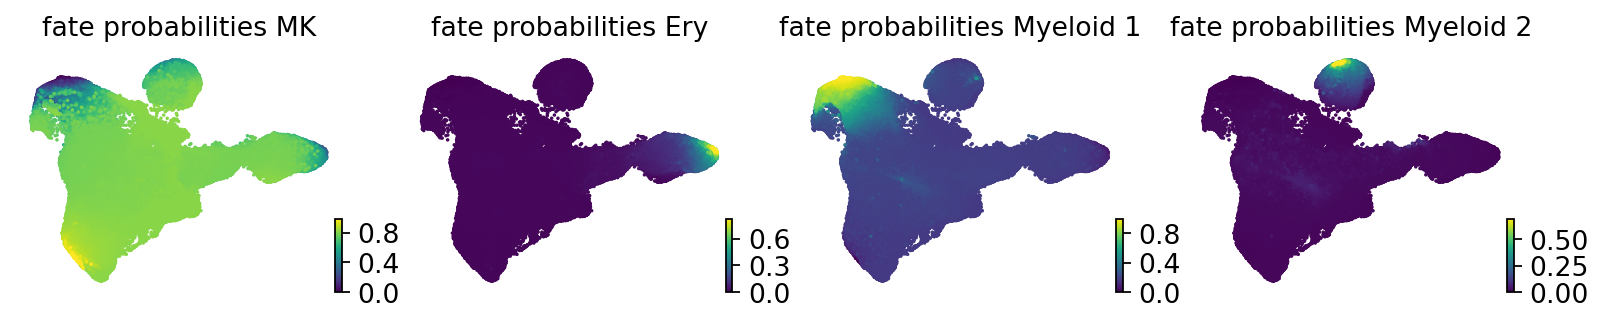

In [ ]:
warnings.filterwarnings('ignore')
g.compute_fate_probabilities(tol=1e-20)
g.plot_fate_probabilities(same_plot=False, size=10, basis="umap_integrated",
                                save="cytoTRACE_predicted_terminal_macrostates_fate_prob.png")

Correlate fate probabilities with gene expression

## Uncover driver genes

Computing driver genes for all trajectories, and visualize itegration makers for the MK and Ery lineages.

Adding `adata.varm['terminal_lineage_drivers']`
       `.lineage_drivers`
    Finish (0:00:27)
Adjusting text position
    Finish (0:00:09)


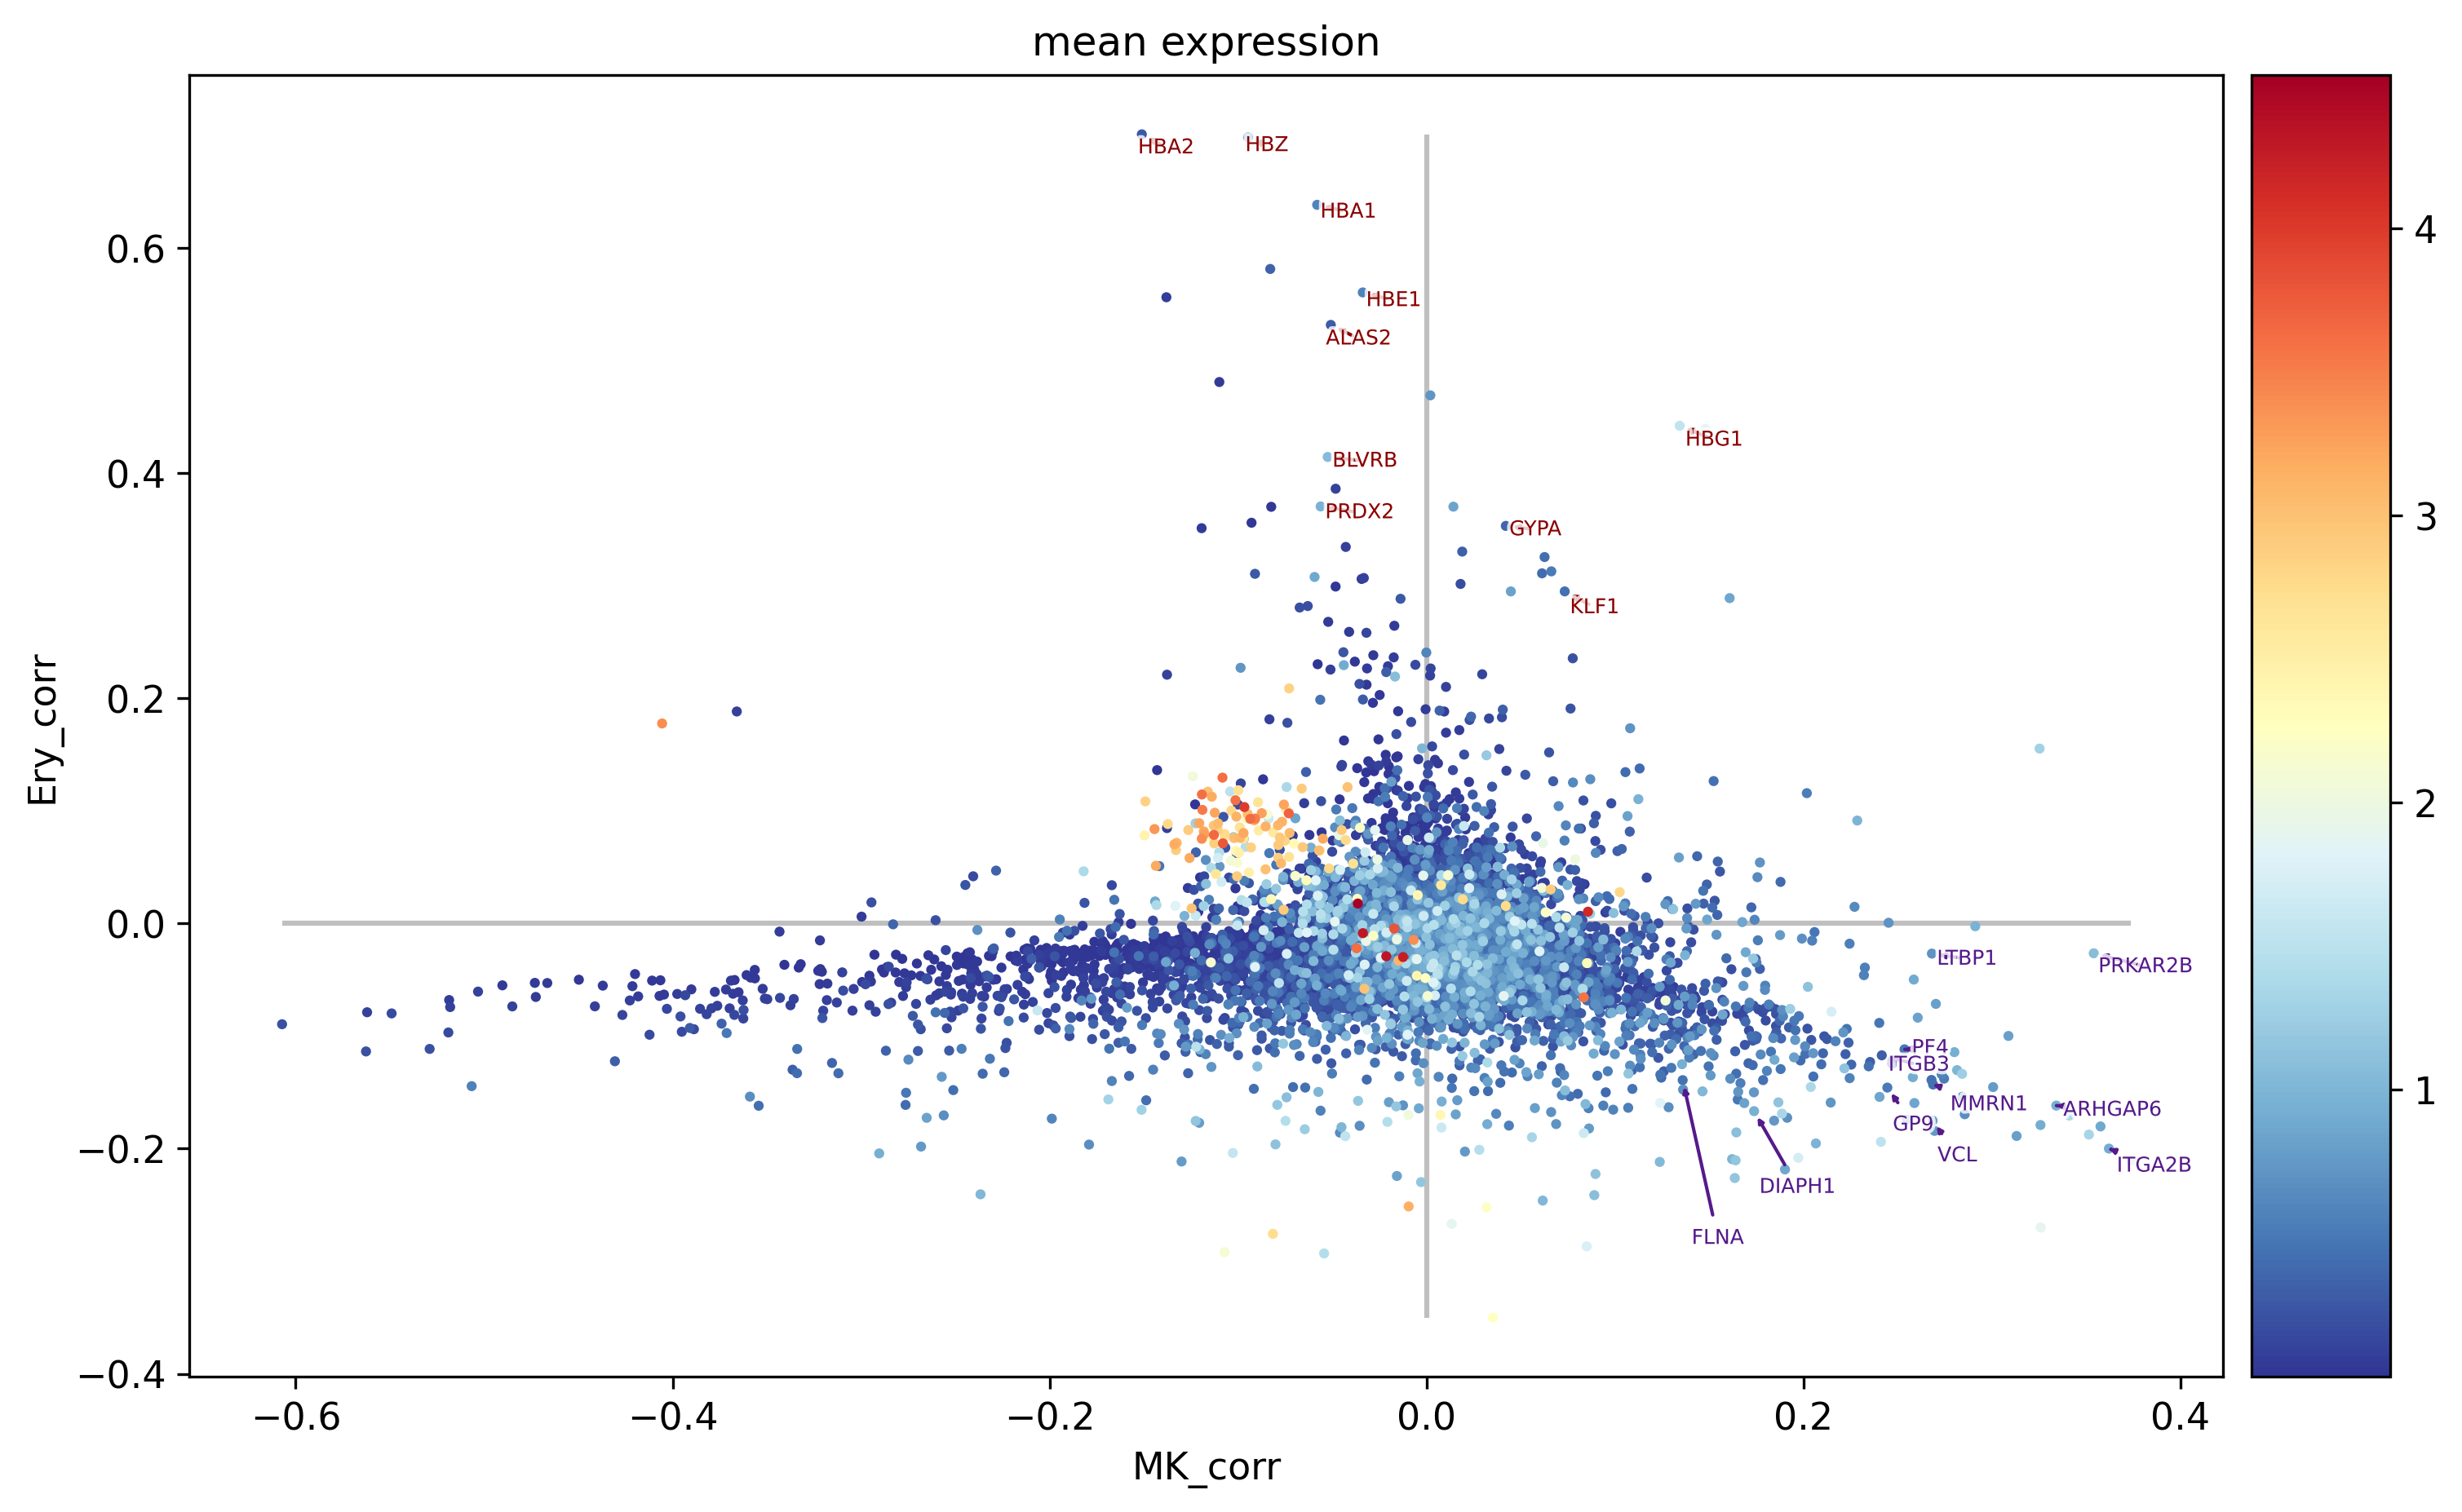

In [ ]:
# compute driver genes
driver_df = g.compute_lineage_drivers()
driver_df.to_csv("../results/timecourse/timecourse-d7911-renamed-pub-lineage_drivers.csv.gz", index=True)
adata.write("../seurat_objects/CellRank_cytoTRACE_predicted_cell_fate_and_driver_genes.h5ad")

# define set of genes to annotate - exclude marker gene that overlap and not visible on the plot
ery_genes = ["HBZ", "KLF1", "HBE1", "GYPA", "BLVRB", "PRDX2", "HBA1", "HBA2", "ALAS2", "HBG1", "HGB2", ]
mk_genes = ["PF4", "GP9", "DIAPH1", "FLNA", "DAAMI", "VCL", "LTBP1", "ITGA2B", "PRKAR2B", "ARHGAP6", "MMRN1", "ITGB3", "MED127"]

genes_oi = {
    "Ery": ery_genes,
    "MK": mk_genes,
}

# make sure all of these exist in AnnData
assert [
    gene in adata.var_names for genes in genes_oi.values() for gene in genes
], "Did not find all genes"

# compute mean gene expression across all cells
adata.var["mean expression"] = adata.X.A.mean(axis=0)

# visualize in a scatter plot
g.plot_lineage_drivers_correlation(
    lineage_x="MK",
    lineage_y="Ery",
    adjust_text=True,
    gene_sets=genes_oi,
    color="mean expression",
    legend_loc="none",
    figsize=(9, 7),
    dpi=150,
    fontsize=6,
    size=35,
    save="cytoTRACE_predicted_terminal_macrostates_MK_vs_Ery_integration_markers.png"
)

## Visualize expression cascades/trands via heatmaps

Add latent time from scVelo to the metadata (adata.obs) to use for pseudotemporalordering with CellRank's fate probabilities to visualize each gene's expression along specific trajectories (intial to termiates states along a lineage). CellRank's ct_pseudotime a bit more re-oreinting in order to obtain the correct expression cascades of sequential activation.

In [ ]:
latent_time = pd.read_csv("../results/timecourse/timecourse-d7911-renamed-pub-latent-time.csv.gz")[["barcode", "latent_time"]]
latent_time
adata.obs = adata.obs.merge(latent_time, on='barcode', how='left')
adata

AnnData object with n_obs × n_vars = 148750 × 29918
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'seurat_clusters', 'integrated_snn_res.0.4', 'cell_type', 'S.Score', 'G2M.Score', 'Phase', 'barcode', 'condition', 'genotype', 'time', 'sample_batch', 'batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'ct_score', 'ct_pseudotime', 'ct_num_exp_genes', 'macrostates_fwd', 'term_states_fwd', 'term_states_fwd_probs', 'latent_time'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'n_cells', 'gene_count_corr', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'ct_gene_corr', 'ct_correlates', 'mean expression'
    uns: 'cell_type_colors', 'time_colors', 'log1p', 'hvg', 'neighbors', 'ct_params', 'T_fwd_params', 'schur_matrix_fwd', 'eigendecomposition_fwd', 'macrostates_fwd_colors', 'coarse_fwd', 'term_states_fwd_colors'
    obsm: 'X_pca', 'X_umap_integrated', 'X_umap_merged', 'T_fwd_umap_integrated', 'schur_vectors_f

Plot heatmap top 100 dirver genes for each terminal lineage

In [ ]:
# run model
model = cr.models.GAM(adata)

Adding `adata.varm['terminal_lineage_drivers']`
       `.lineage_drivers`
    Finish (0:00:23)
Computing trends using `1` core(s)


  0%|          | 0/1500 [00:00<?, ?gene/s]

did not converge
did not converge
did not converge
did not converge
did not converge
    Finish (1:06:45)


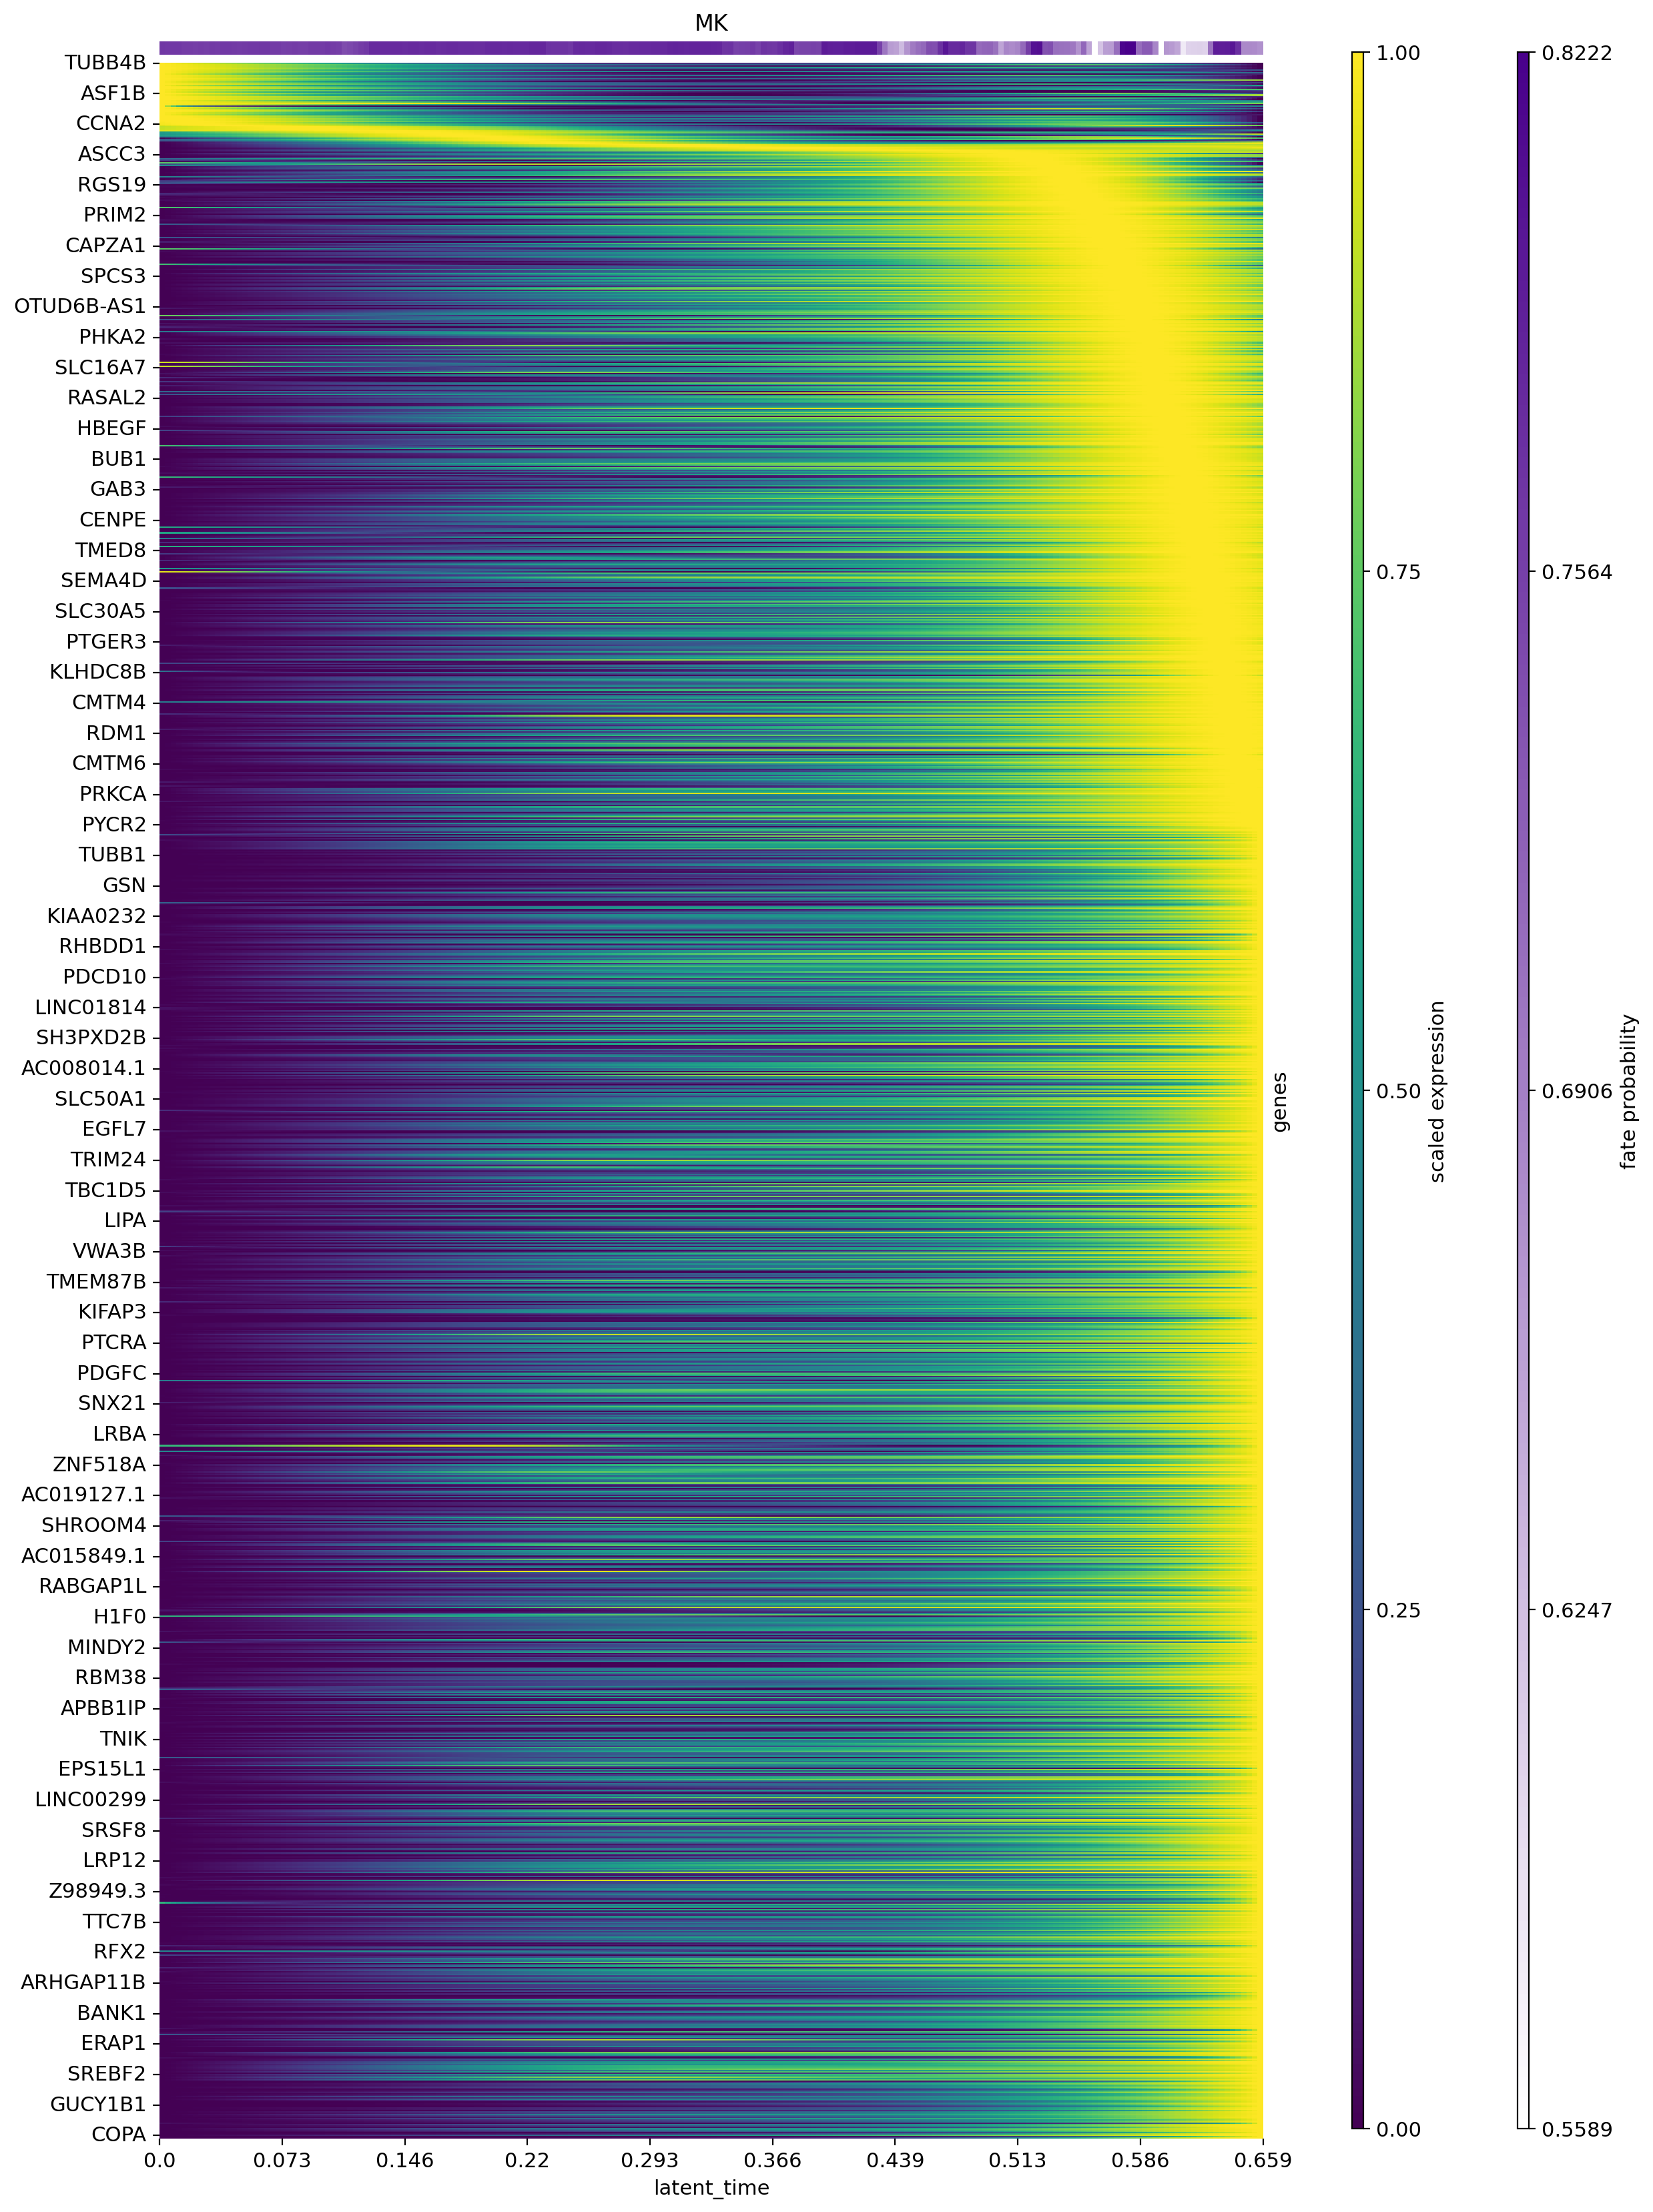

In [ ]:
# MK
mk_driver_clusters = ["HPCs", "HPC - MK bias 2", "HPC - MK bias 1", "MK"]

mk_df = g.compute_lineage_drivers(
    lineages=["MK"], cluster_key="cell_type", clusters=mk_driver_clusters
)

cr.pl.heatmap(
    adata,
    model=model,
    lineages="MK",
    cluster_key=None,
    show_fate_probabilities=True,
    genes=mk_df["MK_corr"].sort_values(ascending=False).index[:1500],
    #genes=mk_df.head(100).index,
    time_key="latent_time",
    figsize=(12, 20),
    show_all_genes= False,
    weight_threshold=(1e-3, 1e-3),
    save="cytoTRACE_predicted_terminal_macrostates_MK_driver_genes.png"
)

Adding `adata.varm['terminal_lineage_drivers']`
       `.lineage_drivers`
    Finish (0:00:06)
Computing trends using `1` core(s)


  0%|          | 0/1500 [00:00<?, ?gene/s]

did not converge


[0]PETSC ERROR: ------------------------------------------------------------------------
[0]PETSC ERROR: Caught signal number 13 Broken Pipe: Likely while reading or writing to a socket
[0]PETSC ERROR: Try option -start_in_debugger or -on_error_attach_debugger
[0]PETSC ERROR: or see https://petsc.org/release/faq/#valgrind and https://petsc.org/release/faq/
[0]PETSC ERROR: configure using --with-debugging=yes, recompile, link, and run 
[0]PETSC ERROR: to get more information on the crash.
Abort(59) on node 0 (rank 0 in comm 0): application called MPI_Abort(MPI_COMM_WORLD, 59) - process 0


    Finish (0:53:24)


Abort(59) on node 0 (rank 0 in comm 0): application called MPI_Abort(MPI_COMM_WORLD, 59) - process 0


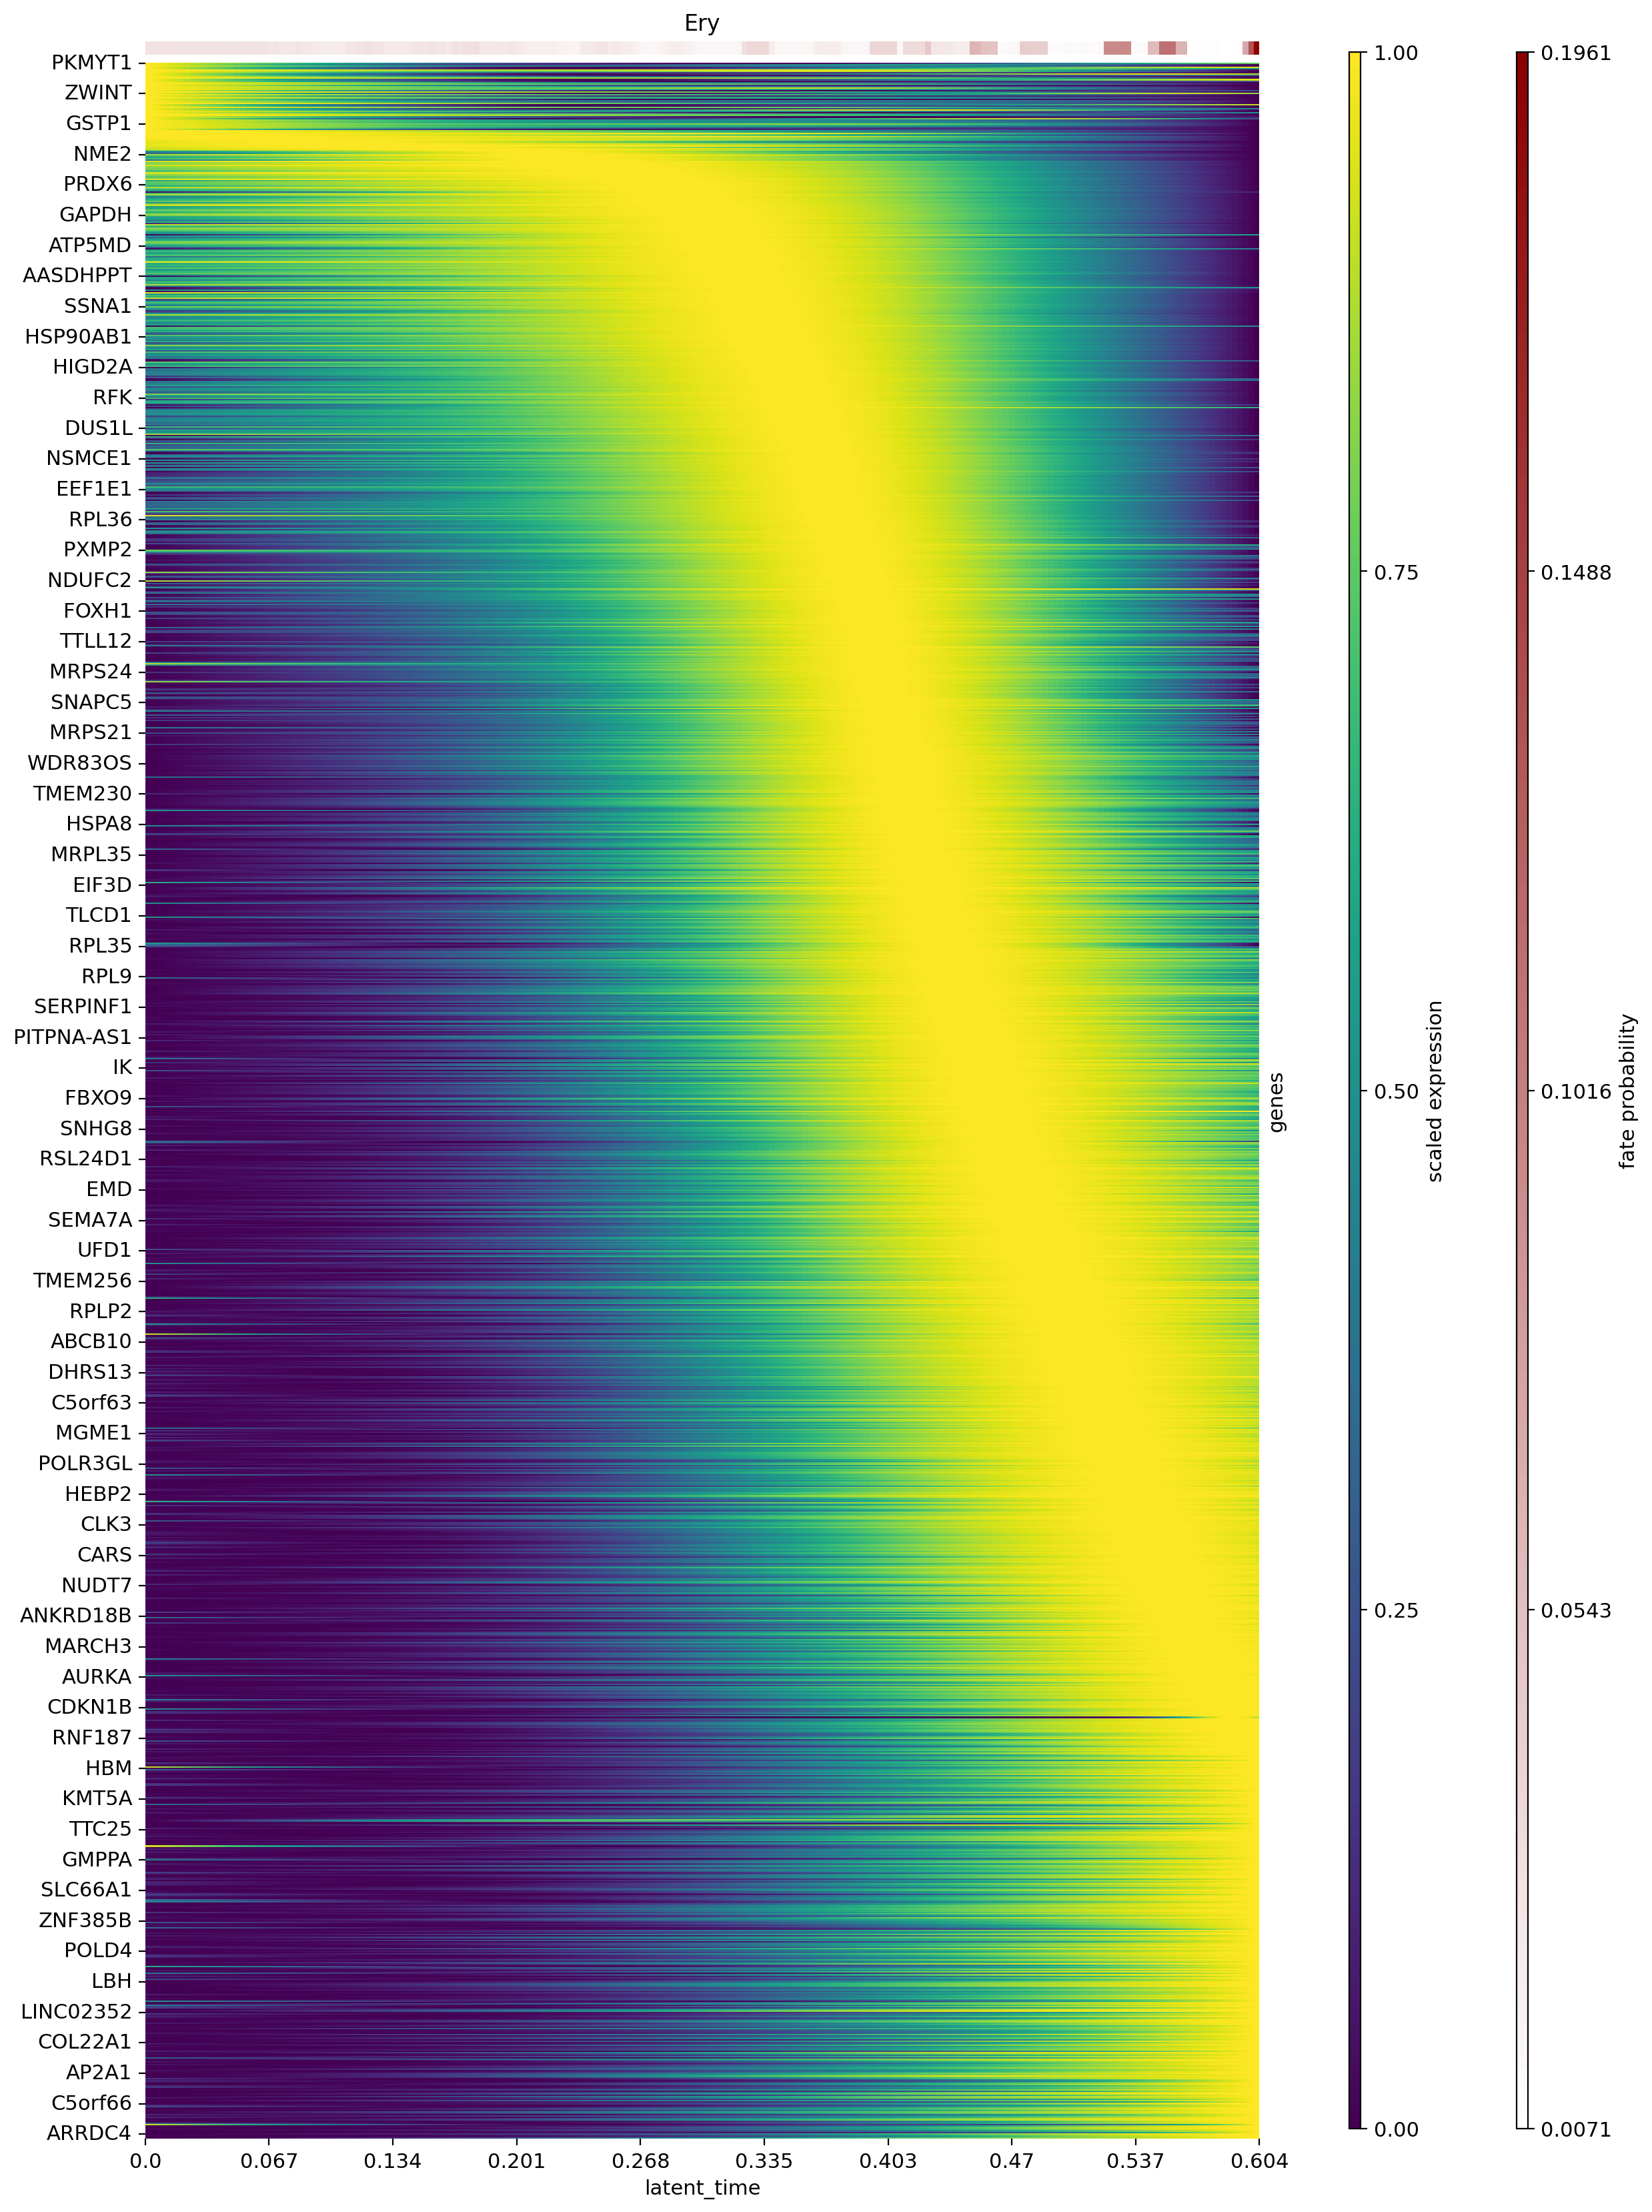

In [ ]:
# Ery
ery_driver_clusters = ["HPCs", "HPC - Ery bias", "Ery"]

ery_df = g.compute_lineage_drivers(
    lineages=["Ery"], cluster_key="cell_type", clusters=ery_driver_clusters
)

cr.pl.heatmap(
    adata,
    model=model,
    lineages="Ery",
    cluster_key=None,
    show_fate_probabilities=True,
    genes=ery_df["Ery_corr"].sort_values(ascending=False).index[:1500],
    #genes=adata.varm["terminal_lineage_drivers"]["Ery_corr"].sort_values(ascending=False).index[:100],
    #genes=ery_df.head(100).index,
    time_key="latent_time",
    figsize=(12, 20),
    show_all_genes=False,
    weight_threshold=(1e-3, 1e-3),
    save="cytoTRACE_predicted_terminal_macrostates_Ery_driver_genes.png"
)

Adding `adata.varm['terminal_lineage_drivers']`
       `.lineage_drivers`
    Finish (0:00:05)
Computing trends using `1` core(s)


  0%|          | 0/1500 [00:00<?, ?gene/s]

[0]PETSC ERROR: ------------------------------------------------------------------------
[0]PETSC ERROR: Caught signal number 13 Broken Pipe: Likely while reading or writing to a socket
[0]PETSC ERROR: Try option -start_in_debugger or -on_error_attach_debugger
[0]PETSC ERROR: or see https://petsc.org/release/faq/#valgrind and https://petsc.org/release/faq/
[0]PETSC ERROR: configure using --with-debugging=yes, recompile, link, and run 
[0]PETSC ERROR: to get more information on the crash.
Abort(59) on node 0 (rank 0 in comm 0): application called MPI_Abort(MPI_COMM_WORLD, 59) - process 0


    Finish (1:01:51)


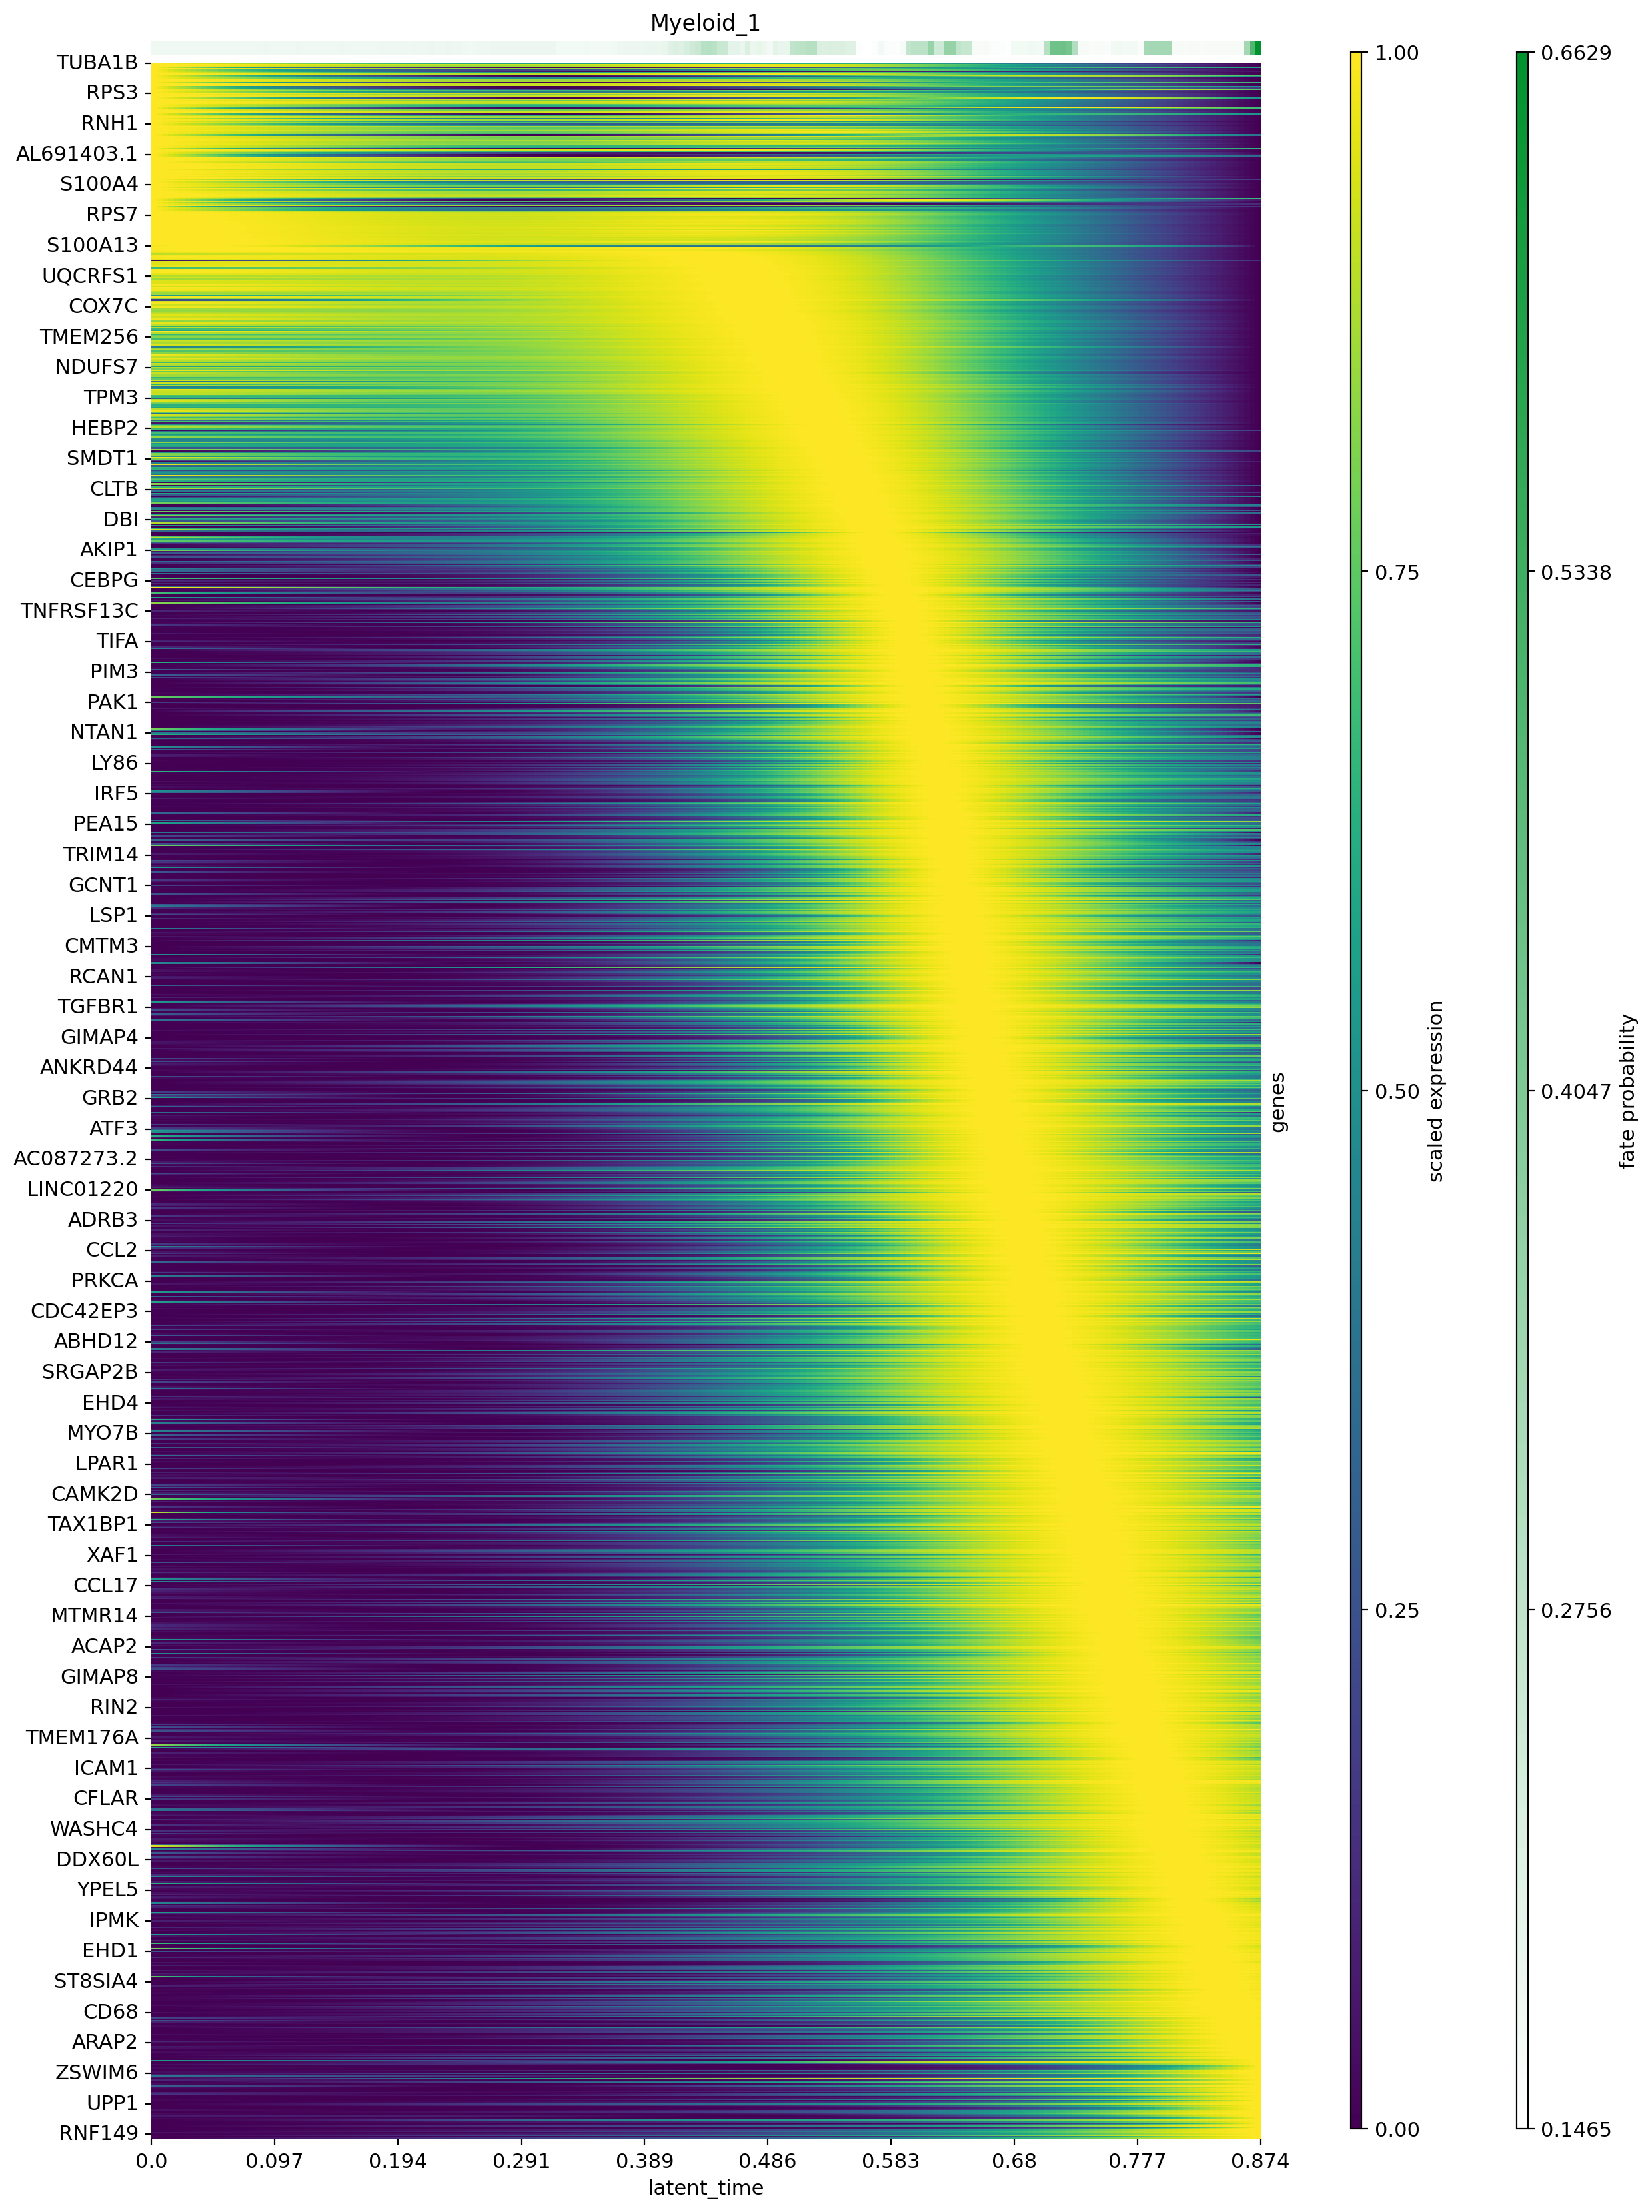

In [ ]:
# Myeloid 1
myeloid1_driver_clusters = ["HPCs", "Myeloid"]

myeloid1_df = g.compute_lineage_drivers(
    lineages=["Myeloid_1"], cluster_key="cell_type", clusters=myeloid1_driver_clusters
)

cr.pl.heatmap(
    adata,
    model=model,
    lineages="Myeloid_1",
    cluster_key=None,
    show_fate_probabilities=True,
    genes=myeloid1_df["Myeloid_1_corr"].sort_values(ascending=False).index[:1500],
    #genes=myeloid1_df.head(100).index,
    time_key="latent_time",
    figsize=(12, 20),
    show_all_genes=False,
    weight_threshold=(1e-3, 1e-3),
    save="cytoTRACE_predicted_terminal_macrostates_myeloid1_driver_genes.png"
)

Adding `adata.varm['terminal_lineage_drivers']`
       `.lineage_drivers`
    Finish (0:00:09)
Computing trends using `1` core(s)


  0%|          | 0/1500 [00:00<?, ?gene/s]

did not converge


[0]PETSC ERROR: ------------------------------------------------------------------------
[0]PETSC ERROR: Caught signal number 13 Broken Pipe: Likely while reading or writing to a socket
[0]PETSC ERROR: Try option -start_in_debugger or -on_error_attach_debugger
[0]PETSC ERROR: or see https://petsc.org/release/faq/#valgrind and https://petsc.org/release/faq/
[0]PETSC ERROR: configure using --with-debugging=yes, recompile, link, and run 
[0]PETSC ERROR: to get more information on the crash.
Abort(59) on node 0 (rank 0 in comm 0): application called MPI_Abort(MPI_COMM_WORLD, 59) - process 0


    Finish (0:50:32)


Abort(59) on node 0 (rank 0 in comm 0): application called MPI_Abort(MPI_COMM_WORLD, 59) - process 0


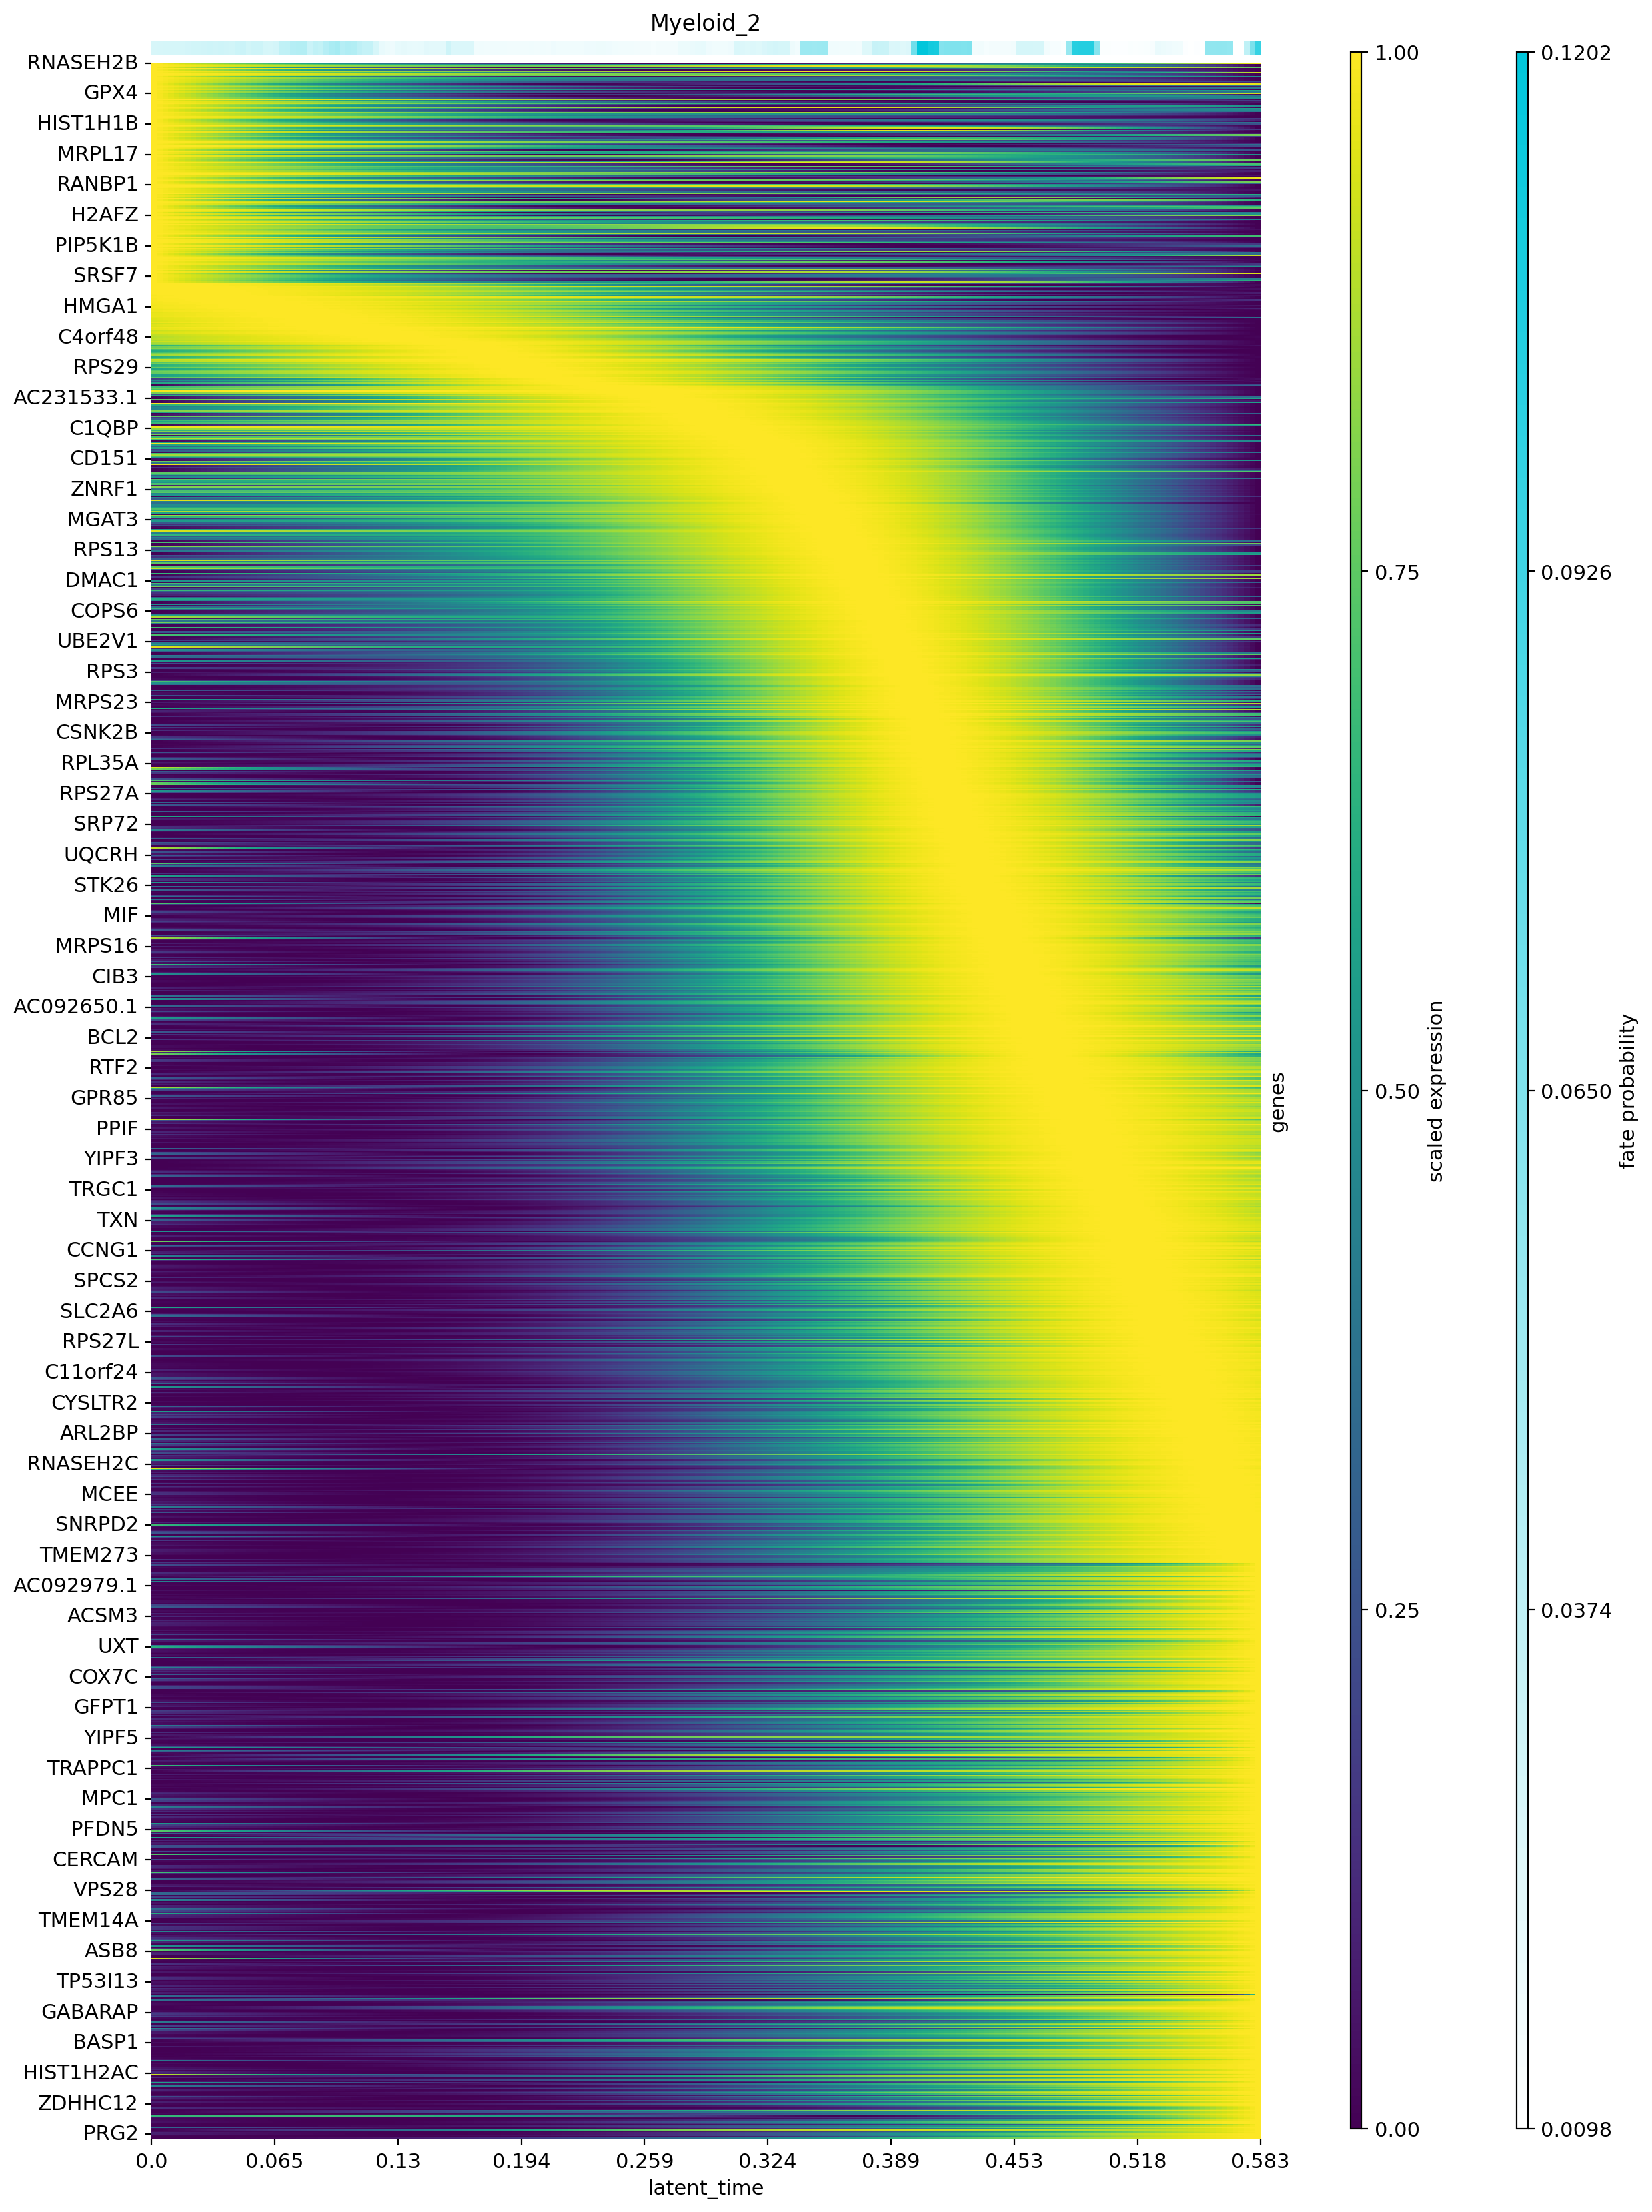

In [ ]:
# Myeloid 2
myeloid2_driver_clusters = ["HPCs", "Myeloid"]

myeloid2_df = g.compute_lineage_drivers(
    lineages=["Myeloid_2"], cluster_key="cell_type", clusters=myeloid2_driver_clusters
)

cr.pl.heatmap(
    adata,
    model=model,
    lineages="Myeloid_2",
    cluster_key=None,
    show_fate_probabilities=True,
    genes=myeloid2_df["Myeloid_2_corr"].sort_values(ascending=False).index[:1500],
    #genes=myeloid2_df.head(100).index,
    time_key="latent_time",
    figsize=(12, 20),
    show_all_genes=False,
    weight_threshold=(1e-3, 1e-3),
    save="cytoTRACE_predicted_terminal_macrostates_myeloid2_driver_genes.png"
)

In [ ]:
adata

AnnData object with n_obs × n_vars = 148750 × 29918
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'seurat_clusters', 'integrated_snn_res.0.4', 'cell_type', 'S.Score', 'G2M.Score', 'Phase', 'barcode', 'condition', 'genotype', 'time', 'sample_batch', 'batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'ct_score', 'ct_pseudotime', 'ct_num_exp_genes', 'macrostates_fwd', 'term_states_fwd', 'term_states_fwd_probs', 'latent_time'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'n_cells', 'gene_count_corr', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'ct_gene_corr', 'ct_correlates', 'mean expression'
    uns: 'cell_type_colors', 'time_colors', 'log1p', 'hvg', 'neighbors', 'ct_params', 'T_fwd_params', 'schur_matrix_fwd', 'eigendecomposition_fwd', 'macrostates_fwd_colors', 'coarse_fwd', 'term_states_fwd_colors'
    obsm: 'X_pca', 'X_umap_integrated', 'X_umap_merged', 'T_fwd_umap_integrated', 'schur_vectors_f